In [1]:
# Zachary Katz
# zachary_katz@mines.edu


"""
Plot Figures 3,4,S3,S4,S5,S8,S9,S10 for Whillans Catalog Paper
Figure 3: Events on top of tides
Figure 4: 3 Day spectrogram and 45 day rolling mean and spectra
Figure S3: Tides across basin
Figure S4: 3-Day Rolling Mean
Figure S5: 27-Day Rolling Mean
Figure S6


v1.0: 01 November 2024
    Plots for Whillans Catalog Paper
v2.0: 08 March 2025
    Paper Version
"""

# Imports
import datetime
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable


import pandas as pd
import numpy as np
import scipy
import math


from astropy.timeseries import LombScargle

from pyproj import CRS, Transformer
import shapefile
import shapely
from shapely.plotting import plot_line
from shapely.geometry import LineString

from cmap import Colormap
import xarray as xr
import rasterio
from matplotlib.lines import Line2D

%reload_ext autoreload
%autoreload


################################################################################
########################## User Defined Variables ##############################

min_stas = 2  # Which catalog to use
tide_dir = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background"
tide_mod = "CATS2008-v2023"

# Path to Tides
# Likely should be "{pwd}/src/Tides"
path = (
    "/mnt/c/users/ZacharyKatz/Desktop/Papers/WhillansCatPaper/WhillansCatalogPaper/src/"
)

# Path to background data files
# {path_to_dir}/scripps_antarctica_polygons_v1.shp
gl_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/Antarctica_masks/scripps_antarctica_polygons_v1.shp"
vel_mag_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/antarctic_ice_vel_phase_map_v01-vmag.nc"
moa_path = (
    "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/moa750_2009_hp1_v1.1.tif"
)
########################## User Defined Variables ##############################
################################################################################

sys.path.insert(
    0,
    path,
)

In [ ]:
import Tides.Tides as Tides

# Load slip times based on second derivative
ev_data = {"event": [], "trace_time": []}
df = pd.read_csv(f"../AllEventStartTimes{min_stas}stas.txt", sep="\t")
ev_data["ev_time"] = df["EventStartTime"]

# Load no data from txt file
no_data = {"interval": [], "starts": [], "ends": []}
df = pd.read_csv(f"../no_data_{min_stas}stas.txt", sep="\t")
no_data["starts"] = df["start"]
no_data["ends"] = df["end"]
diff = [
    datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S")
    - datetime.datetime.strptime(y, "%Y-%m-%d %H:%M:%S")
    for x, y in zip(no_data["ends"], no_data["starts"])
]
no_data["interval"] = diff
print(len(ev_data["ev_time"]), "events loaded")

5150 events loaded


In [3]:
# Calculate time since last events
time_since_last_ev = [
    datetime.timedelta(seconds=1000000)
]  # Set large for first event because prior event time unknown
for i, event in enumerate(ev_data["ev_time"]):
    if i > 0:
        current = datetime.datetime.strptime(event, "%Y-%m-%d %H:%M:%S")
        prior = datetime.datetime.strptime(
            ev_data["ev_time"][i - 1], "%Y-%m-%d %H:%M:%S"
        )
        diff = current - prior
        # Check if data gap in current - prior and remove event from consideration
        for j, gap in enumerate(no_data["interval"]):
            if (
                prior
                < datetime.datetime.strptime(no_data["ends"][j], "%Y-%m-%d %H:%M:%S")
                < current
            ):
                diff = datetime.timedelta(seconds=1000000)
        time_since_last_ev.append(diff)
ev_data["time_since_last_ev"] = time_since_last_ev
print([(a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]])
tsle = [
    i
    for i, x in enumerate(ev_data["time_since_last_ev"])
    if x == datetime.timedelta(seconds=1000000)
]
print(len(tsle))

[277.77777777777777, 17.354166666666668, 21.766666666666666, 10.758333333333333, 13.254166666666666, 19.1125, 22.970833333333335, 10.4875, 11.895833333333334, 9.975, 14.345833333333333, 9.975, 14.845833333333333, 9.9875, 14.658333333333333, 12.0625, 13.1375, 9.808333333333334, 15.225, 10.9875, 14.591666666666667, 10.625, 15.1, 23.866666666666667, 8.416666666666666, 16.3375, 21.929166666666667, 10.666666666666666, 14.5875, 18.954166666666666, 14.941666666666666, 10.7375, 20.645833333333332, 13.025, 12.041666666666666, 11.0125, 13.125, 9.525, 15.145833333333334, 8.875, 15.625, 8.2875, 16.266666666666666, 8.525, 16.9125, 8.5125, 16.4875, 8.55, 19.804166666666667, 16.733333333333334, 11.6625, 12.2, 12.983333333333333, 13.9, 21.4, 20.2, 12.008333333333333, 11.979166666666666, 11.516666666666667, 12.891666666666667, 11.183333333333334, 13.1125, 11.1, 13.5125, 11.545833333333333, 13.420833333333333, 10.85, 14.083333333333334, 10.420833333333333, 14.325, 11.045833333333333, 16.941666666666666,

[(-174.11568595746584, -84.38504722396503), (-174.07363790894706, -84.38708087490528), (-174.03252834334145, -84.38929637003153), (-173.9941263318061, -84.39193572017322), (-173.95194821792526, -84.39181611372216), (-173.90710899077706, -84.39045168887456), (-173.86118811502547, -84.38949590176401), (-173.8148291962652, -84.38878233553352), (-173.76803047357416, -84.38841239171828), (-173.72112609045024, -84.38834365932638), (-173.6742274584149, -84.38855870689241), (-173.62764576571297, -84.38910967700275), (-173.5814536310214, -84.38993610577346), (-173.53591166420026, -84.3910466307691), (-173.49112552234823, -84.39243260584267), (-173.44773757602218, -84.39419044387766), (-173.40529722592322, -84.39616056496061), (-173.36429498918946, -84.39840763385244), (-173.32440343132876, -84.40084127031444), (-173.28402159579116, -84.40319834133297), (-173.24328319333878, -84.40550028801066), (-173.20251122152564, -84.4077994127134), (-173.16170568018524, -84.41009571193077), (-173.1203332639

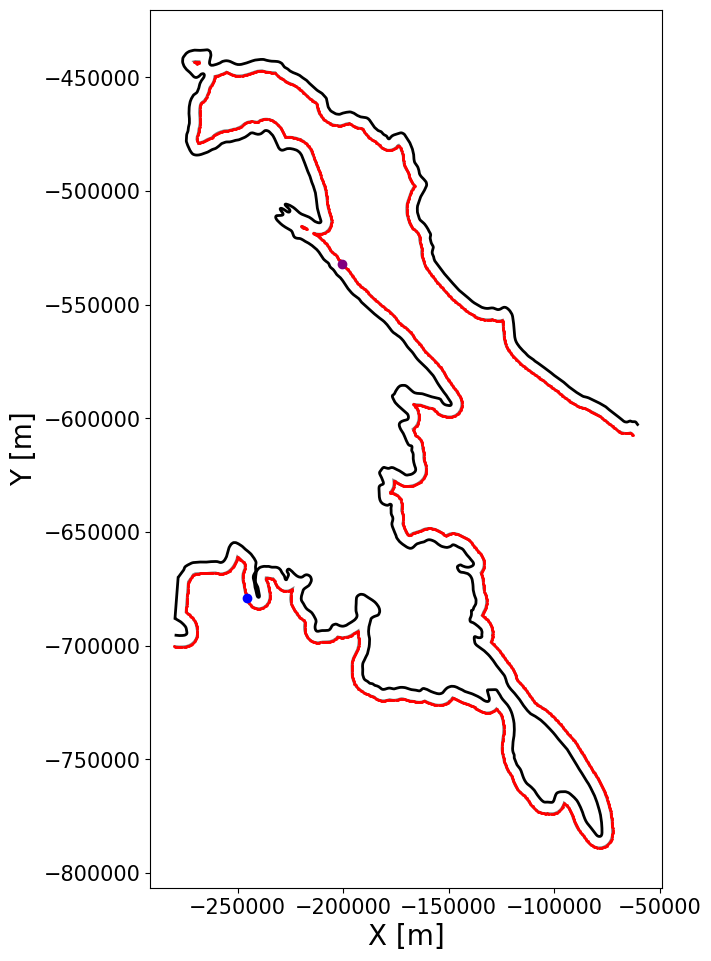

In [4]:
# Calculate difference in tides across basin at event times (from icesat2/gztides.ipynb)
# Helper functions
def inBox(points, bbox):
    # Return points from points that are in bbox
    inbox = []
    for point in points:
        x = point[0]
        y = point[1]
        if x > bbox[0] and x < bbox[2] and y > bbox[1] and y < bbox[3]:
            inbox.append(point)
    return inbox


def interpolateLine(line, dist):
    # Return a new list of points from a linestring that has been interpolated at
    # distance dist. Line must be linestring, dist in m for our case

    # Follows example from:
    # https://stackoverflow.com/questions/34906124/interpolating-every-x-distance-along-multiline-in-shapely
    length = shapely.length(line)
    num_vert = int(np.round(length / dist))
    # print(num_vert)
    return [line.interpolate(n * dist) for n in range(num_vert)]


def xy2ll(x, y):
    """
     Transform coordinates to geodetic coordinates (lon, lat)
     from Antarctic Polar Stereograph coordinates (x, y)

    lon,lat = xy2ll(x,y)
    """
    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    xy_to_ll = Transformer.from_crs(crs_xy, crs_ll, always_xy=True)
    lon, lat = xy_to_ll.transform(x, y)
    return lon, lat


def ll2xy(lon, lat):
    """
    Transform coordinates from input geodetic coordinates (lon, lat)
    to output Antarctic Polar Stereographic coordinates (x, y)
    Can also take lists of floats!

    Parameters
    lon - Geodetic longitude in EPSG:4326 [float]
    lat - Geodetic latitude in EPSG:4326 [float]

    Returns
    x - Antarctic Polar Stereographic (EPSG:3031) x [float]
    y - Antarctic Polar Stereographic (EPSG:3031) y [float]
    """

    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    ll_to_xy = Transformer.from_crs(crs_ll, crs_xy, always_xy=True)
    x, y = ll_to_xy.transform(lon, lat)
    return x, y


def dist_sq(x, y):
    # Returns min dist squared between two points
    delta_x = y[0] - x[0]
    delta_y = y[1] - x[1]
    return delta_x * delta_x + delta_y * delta_y


# Extract coordinates of grounding line

# Tuning parameters
offset = 5000  # Distance from grounding line to offset, m
pt_dist = 500  # Distance between tide sampling points, m

# Arrays to pass to tides
x_tide = []
y_tide = []

bbox = [-280000, -800000, -60000, -420000]  # Includes all of Crary
fig, ax = plt.subplots(
    figsize=[(bbox[2] - bbox[0]) / 100000 * 3, (bbox[3] - bbox[1]) / 100000 * 3]
)
sf = shapefile.Reader(gl_path)
for i, shape in enumerate(sf.shapes(bbox=bbox)):
    if i == 3:
        points = shape.points
        # Only get points within bounding box
        inbox = inBox(points, bbox)
        line = LineString(inbox)
        dilated = line.buffer(3000, single_sided=True)
        offset_line = line.offset_curve(offset)
        plot_line(line, ax=ax, add_points=False, color="black")
        plot_line(offset_line, ax=ax, add_points=False, color="gray")
        # plot_polygon(dilated, ax=ax, add_points=False, color='black')

        interpolated = interpolateLine(offset_line, pt_dist)
        xs = [point.x for point in interpolated]
        ys = [point.y for point in interpolated]
        ax.scatter(xs, ys, s=1, color="red")
        x_tide.append(xs)
        y_tide.append(ys)

ax.xaxis.set_major_locator(ticker.MultipleLocator(50000))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50000))
ax.set_xlabel("X [m]", size=20)
ax.set_ylabel("Y [m]", size=20)
ax.tick_params(labelsize=15)

# Flatten the list. Not sure why this works but here's the source
# https://www.scaler.com/topics/flatten-list-python/
x_tide = sum(x_tide, [])
y_tide = sum(y_tide, [])

lon_lats = [xy2ll(x0, y0) for x0, y0 in zip(x_tide, y_tide)]
lons = [x[0] for x in lon_lats]
lats = [x[1] for x in lon_lats]
print(lon_lats)

x_south = lon_lats[900][0]
y_south = lon_lats[900][1]
x_north = lon_lats[-200][0]
y_north = lon_lats[-200][1]
x_n, y_n = ll2xy(x_north, y_north)
x_s, y_s = ll2xy(x_south, y_south)
ax.scatter(x_n, y_n, color="blue", zorder=2)
ax.scatter(x_s, y_s, color="purple", zorder=2)

In [5]:
path_to_gz = "/mnt/c/Users/ZacharyKatz/Desktop/2018_GZ/Antarctic_GZ_2018_v01.0.shp"
gz = shapefile.Reader(path_to_gz)

fields = gz.fields[1:]  # Skip deletion flag
field_names = [field[0] for field in fields]

records = gz.records()
shapes_gz = gz.shapes()

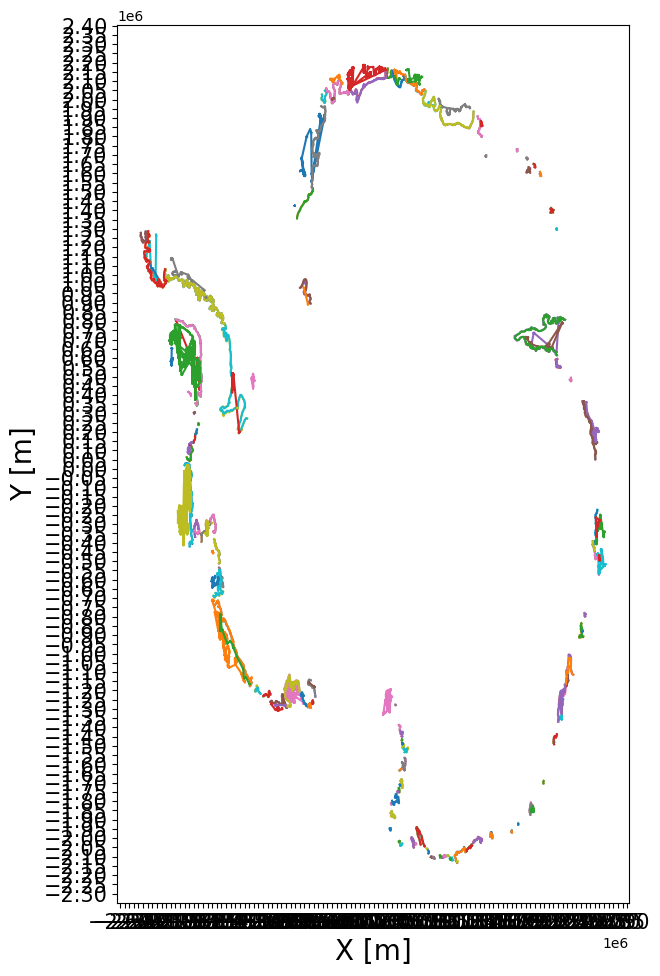

In [6]:
bbox = [-280000, -800000, -60000, -420000]  # Includes all of Crary
fig, ax = plt.subplots(
    figsize=[(bbox[2] - bbox[0]) / 100000 * 3, (bbox[3] - bbox[1]) / 100000 * 3]
)
sf = shapefile.Reader(gl_path)
for i, shape in enumerate(sf.shapes(bbox=bbox)):
    if i == 3:
        points = shape.points
        # Only get points within bounding box
        inbox = inBox(points, bbox)
        line = LineString(inbox)
        dilated = line.buffer(3000, single_sided=True)
        offset_line = line.offset_curve(offset)
        # plot_line(line, ax=ax, add_points=False, color="black")
        # plot_polygon(dilated, ax=ax, add_points=False, color='black')

        interpolated = interpolateLine(offset_line, pt_dist)
        xs = [point.x for point in interpolated]
        ys = [point.y for point in interpolated]
        x_tide.append(xs)
        y_tide.append(ys)

ax.xaxis.set_major_locator(ticker.MultipleLocator(50000))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50000))
ax.set_xlabel("X [m]", size=20)
ax.set_ylabel("Y [m]", size=20)
ax.tick_params(labelsize=15)

for shape in shapes_gz:
    x = [point[0] for point in shape.points]
    y = [point[1] for point in shape.points]
    plt.plot(x, y)

In [7]:
x, y = ll2xy(-165.607194, -84.252568)
print(x, y)

-155349.0842199177 -605360.2745209549


[-62593.440298971465, -63016.262162440245, -63426.72885198084, -63803.32861822993, -64251.12006032353, -64741.448041472104, -65238.66050305062, -65737.79263011392, -66237.60086600333, -66734.9613396404, -67228.82329973437, -67715.18756836123, -68193.93486542544, -68662.13336939174, -69118.70502341053, -69555.60020087584, -69979.50116592874, -70384.3764211318, -70774.78343900069, -71170.9365012661, -71571.16062239397, -71971.38474352178, -72371.60886464946, -72778.65610430592, -73185.85611203789, -73593.05611976978, -74000.25612750137, -74407.45613523344, -74814.65614296516, -75221.85615069704, -75629.0561584288, -76036.25616616069, -76443.45617389253, -76843.3949710638, -77235.73406987752, -77621.3035245648, -78006.87297925178, -78404.33373114694, -78844.54962243764, -79284.76551372795, -79724.98140501887, -80165.19729630939, -80605.41318759977, -81054.42103435477, -81508.4711856762, -81962.52133699808, -82416.57148831968, -82870.62163964126, -83324.67179096291, -83778.72194228432, -84

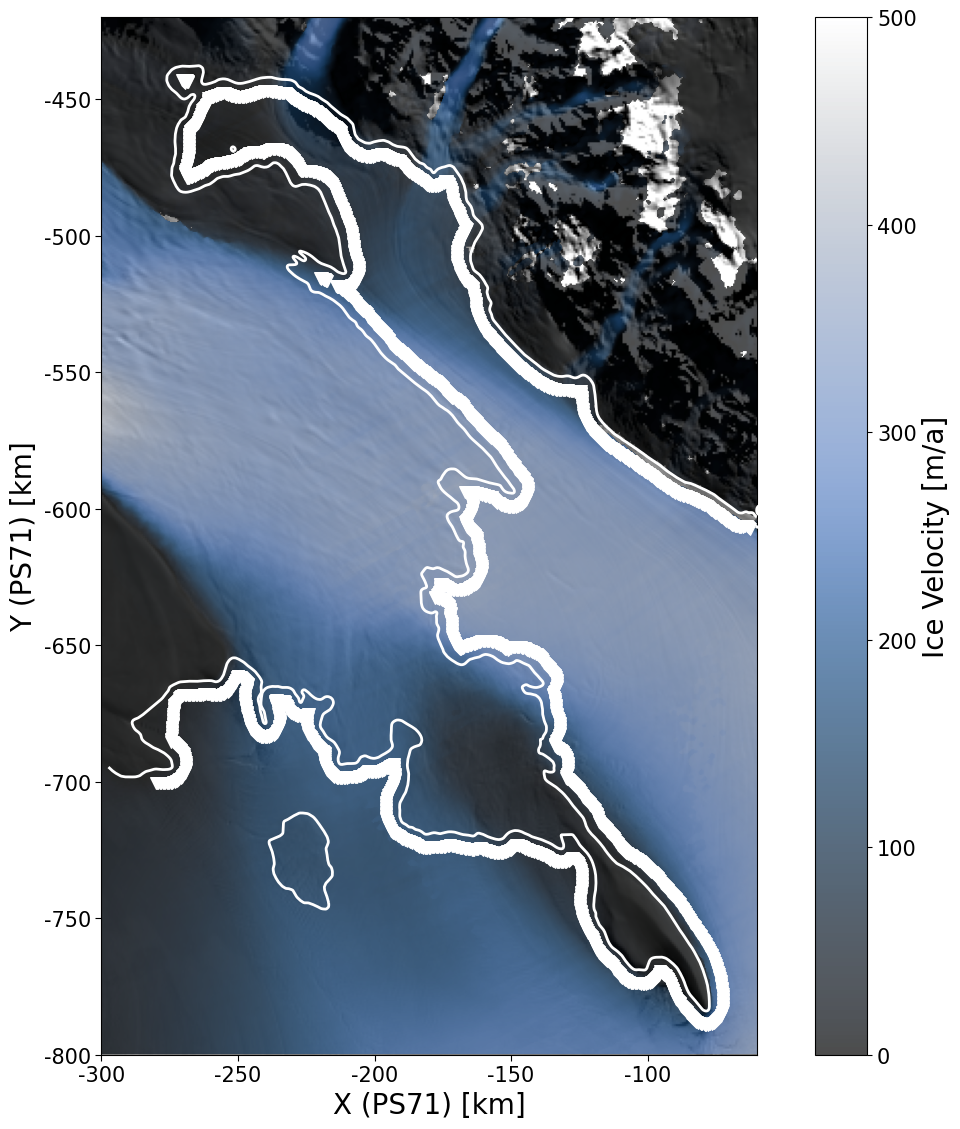

In [8]:
# Plot tide locations
vel_mag = xr.open_dataarray(vel_mag_path)
bbox = [-300000, -800000, -60000, -420000]  # Includes all of Crary
vel_mag = vel_mag.isel(x=slice(4000, 8000), y=slice(6000, 8000))
x_min_v, x_max_v = vel_mag["x"].min().item(), vel_mag["x"].max().item()
y_min_v, y_max_v = vel_mag["y"].min().item(), vel_mag["y"].max().item()

with rasterio.open(moa_path) as moa:
    bounds = moa.bounds
    left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
    moa_dat = moa.read(1)

ext = (left, right, bottom, top)


oslo = Colormap("crameri:oslo").to_mpl()
# Static frame
sf = shapefile.Reader(gl_path)
fig, ax = plt.subplots(
    figsize=[(bbox[2] - bbox[0]) / 100000 * 5, (bbox[3] - bbox[1]) / 100000 * 3]
)
fig.set_tight_layout(True)
ax.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
v = ax.imshow(
    vel_mag,
    extent=(x_min_v, x_max_v, y_min_v, y_max_v),
    cmap=oslo,
    vmax=500,
    vmin=0,
    alpha=0.7,
)
for i, shape in enumerate(sf.shapes(bbox=bbox)):
    if i > 0:
        points = shape.points
        # Only get points within bounding box
        inbox = inBox(points, bbox)
        line = LineString(inbox)
        plot_line(line, ax=ax, add_points=False, color="white")
x_min, x_max = bbox[0], bbox[2]
y_min, y_max = bbox[1], bbox[3]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
KM_SCALE = 1e3
ticks_x = ticker.FuncFormatter(lambda x, pos: "{0:g}".format(x / KM_SCALE))
ax.xaxis.set_major_formatter(ticks_x)
ticks_y = ticker.FuncFormatter(lambda x, pos: "{0:g}".format(x / KM_SCALE))
ax.yaxis.set_major_formatter(ticks_y)
ax.set_xlabel("X (PS71) [km]", size=20)
ax.set_ylabel("Y (PS71) [km]", size=20)
ax.tick_params(labelsize=15)
ax.tick_params(size=4)
# ax.set_facecolor("black")
cbarv = fig.colorbar(v)
cbarv.ax.tick_params(labelsize=15)
cbarv.ax.set_ylabel("Ice Velocity [m/a]", size=20)
x, y = ll2xy(lons, lats)
places = ["gz05", "North", "South"]
ax.scatter(x, y, s=70, color="white", marker="v")
print(x)
ax.text(x[0] + 2000, y[0], "gz05", color="white", size=25)
ax.text(x[1] + 2000, y[1], "North", color="white", size=25)
ax.text(x[2] + 2000, y[2], "South", color="white", size=25)

fig.tight_layout()

In [10]:
# Tide time series at gz05
spacing = 4  # Minutes
dates_timeseries = []
initial_time = datetime.datetime.strptime("2007-12-01 00:00:00", "%Y-%m-%d %H:%M:%S")
for i in range(24 * 365 * 12 * 15):  # 15 tides/min * 24 hours * 365 *11 years
    dates_timeseries.append(initial_time + datetime.timedelta(minutes=spacing * i))

lats = [-84.2986, y_north, y_south]
lons = [-164.5206, x_north, x_south]
places = ["gz05", "North", "South"]

tides = Tides.Tide(tide_mod, tide_dir)
for lat, lon, place in zip(lats, lons, places):
    ev_data[f"tides{place}"] = tides.tidal_elevation(
        [lon],
        [lat],
        dates_timeseries,
    ).data.T[0]

['m2', 's2', 'n2', 'k2', 'k1', 'o1', 'p1', 'q1', 'mf', 'mm']
['m2', 's2', 'n2', 'k2', 'k1', 'o1', 'p1', 'q1', 'mf', 'mm']
['m2', 's2', 'n2', 'k2', 'k1', 'o1', 'p1', 'q1', 'mf', 'mm']


In [11]:
# Calculate modfied tidal form factor
# 3 days of tides with a 0.5 day slide

# Convert dates_timeseries to seconds since dates_timeseries[0]
seconds = [(date - dates_timeseries[0]).total_seconds() for date in dates_timeseries]

spacing = 4  # Minutes
mean_days = 3
slide_days = 1
mean_units = int(mean_days * 24 * 60 / spacing)
slide_units = int(slide_days * 24 * 60 / spacing)

HR_TO_SEC = 3600
T_O1 = 25.81933871 * HR_TO_SEC
T_K1 = 23.93447213 * HR_TO_SEC
T_M2 = 12.4206012 * HR_TO_SEC
T_S2 = 12 * HR_TO_SEC


def sines(x, A1, phi1, A2, phi2):
    return A1 * np.sin(2 * np.pi * x / ((T_O1 + T_K1) / 2) + phi1) + A2 * np.sin(
        2 * np.pi * x / ((T_M2 + T_S2) / 2) + phi2
    )


form_factors = []
dates_form_factor = []
semidiurnal = []
diurnal = []
# Extract 3 days of tidal data with a 0.5 day slide
start = 0
end = mean_units
while end < len(seconds):
    seconds_tide = np.array(seconds[start:end], dtype=float)
    tide = np.array(ev_data["tidesgz05"][start:end], dtype=float)
    date_midpoint = dates_timeseries[(start + end) // 2]
    start += slide_units
    end += slide_units

    # Fit a sum of sines to the tide
    initial_guess = [50, 0, 50, 0]
    popt, pcov = scipy.optimize.curve_fit(sines, seconds_tide, tide, p0=initial_guess)

    # Extract fitted parameters
    Diurnal_fit, phi1_fit, SemiDiurnal_fit, phi2_fit = popt

    # Generate the fitted curve
    y_fit = sines(seconds_tide, Diurnal_fit, phi1_fit, SemiDiurnal_fit, phi2_fit)
    form_factor = np.abs(Diurnal_fit / SemiDiurnal_fit)
    semidiurnal.append((SemiDiurnal_fit))
    diurnal.append((Diurnal_fit))

    form_factors.append(form_factor)
    dates_form_factor.append(date_midpoint)

    # fig, ax = plt.subplots()
    # ax.plot(seconds_tide, tide, color="black")
    # ax.plot(seconds_tide, y_fit, color="red")

/tmp/ipykernel_41162/845198044.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = scipy.optimize.curve_fit(sines, seconds_tide, tide, p0=initial_guess)


In [12]:
# Tides at event times
times_to_calculate_tide = ev_data["ev_time"]

dates = [
    datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S") for x in times_to_calculate_tide
]

lats = [-84.2986, y_north, y_south]
lons = [-164.5206, x_north, x_south]
places = ["gz05", "North", "South"]

for lat, lon, place in zip(lats, lons, places):
    print(lat, lon, place)
    ev_data[f"tide_event_time_{place}"] = tides.tidal_elevation(
        [lon], [lat], dates
    ).data.T[0]

-84.2986 -164.5206 gz05
['m2', 's2', 'n2', 'k2', 'k1', 'o1', 'p1', 'q1', 'mf', 'mm']
-83.3600956082108 -160.11756237973356 North
['m2', 's2', 'n2', 'k2', 'k1', 'o1', 'p1', 'q1', 'mf', 'mm']
-84.77190054845641 -159.36363595869744 South
['m2', 's2', 'n2', 'k2', 'k1', 'o1', 'p1', 'q1', 'mf', 'mm']


In [13]:
# Save tides at event times
df = pd.DataFrame(
    data={
        "time": ev_data["ev_time"],
        "tide_event_time": ev_data["tide_event_time_gz05"],
    }
)
df.to_csv("tide_event_time_gz05.txt", index=False, sep="\t")

In [14]:
# Calculate distance between event and nearest low and high tides
def dists(ev_data, place):
    # Calculate tidal maxima and minima for comparison

    # https://stackoverflow.com/questions/4624970/finding-local-maxima-minima-with-numpy-in-a-1d-numpy-array

    # Get as indices
    pks = scipy.signal.find_peaks(ev_data[f"tides{place}"], distance=60 / spacing * 3)[
        0
    ]  # Require 5 hrs between peaks
    vlys = scipy.signal.find_peaks(
        -1 * ev_data[f"tides{place}"], distance=60 / spacing * 3
    )[0]  # Require 5 hrs between valleys

    # Also save as times
    pk_times = [dates_timeseries[pk] for pk in pks]
    vly_times = [dates_timeseries[vly] for vly in vlys]

    # Find skipped low tide events (No event within +- 7 hrs of vly)
    skipped_lows = []
    events = [
        datetime.datetime.strptime(event, "%Y-%m-%d %H:%M:%S")
        for event in ev_data["ev_time"]
    ]
    for i, vly in enumerate(vlys):
        valley = dates_timeseries[vly]
        closest_event = min(events, key=lambda d: abs(d - valley))
        skipped = -1
        if abs(closest_event - valley) > datetime.timedelta(hours=6):
            skipped = 1
        skipped_lows.append(skipped)

    skipped_highs = []
    events = [
        datetime.datetime.strptime(event, "%Y-%m-%d %H:%M:%S")
        for event in ev_data["ev_time"]
    ]
    for i, pk in enumerate(pks):
        peak = dates_timeseries[pk]
        closest_event = min(events, key=lambda d: abs(d - peak))
        skipped = -1
        if abs(closest_event - peak) > datetime.timedelta(hours=6):
            skipped = 1
        skipped_highs.append(skipped)

    vly_date = [dates_timeseries[vly] for vly in vlys]
    vly_tide = [ev_data[f"tides{place}"][vly] for vly in vlys]

    pk_date = [dates_timeseries[pk] for pk in pks]
    pk_tide = [ev_data[f"tides{place}"][pk] for pk in pks]

    dist_to_highs = []
    dist_to_lows = []
    closest_highs = []
    closest_lows = []
    high_closers = []
    ht_to_highs = []
    ht_to_lows = []
    high_ht_closers = []
    for i, event in enumerate(ev_data["ev_time"]):
        event = datetime.datetime.strptime(event, "%Y-%m-%d %H:%M:%S")
        closest_high = min(pk_times, key=lambda d: abs(d - event))
        dist_to_high = event - closest_high
        closest_low = min(vly_times, key=lambda d: abs(d - event))

        ht_to_high = (
            ev_data[f"tide_event_time_{place}"][i]
            - ev_data[f"tides{place}"][pks[pk_times.index(closest_high)]]
        )
        ht_to_low = (
            ev_data[f"tide_event_time_{place}"][i]
            - ev_data[f"tides{place}"][vlys[vly_times.index(closest_low)]]
        )
        ht_to_highs.append(ht_to_high)
        ht_to_lows.append(ht_to_low)

        dist_to_low = event - closest_low
        dist_to_highs.append(dist_to_high)
        dist_to_lows.append(dist_to_low)
        closest_highs.append(closest_high)
        closest_lows.append(closest_low)

        if abs(dist_to_high) < abs(dist_to_low):
            high_closer = 1
        else:
            high_closer = 0
        high_closers.append(high_closer)

        if abs(ht_to_high) < abs(ht_to_low):
            high_closer = 1
        else:
            high_closer = 0
        high_ht_closers.append(high_closer)

    dist_dict = {
        "dist_to_highs": dist_to_highs,
        "dist_to_lows": dist_to_lows,
        "closest_highs": closest_highs,
        "closest_lows": closest_lows,
        "high_closers": high_closers,
        "ht_to_highs": ht_to_highs,
        "ht_to_lows": ht_to_lows,
        "high_ht_closers": high_ht_closers,
        "vly_date": vly_date,
        "vly_tide": vly_tide,
        "pk_date": pk_date,
        "pk_tide": pk_tide,
    }
    return dist_dict

In [15]:
dist_gz05 = dists(ev_data, "gz05")
dist_North = dists(ev_data, "North")
dist_South = dists(ev_data, "South")

In [16]:
spacing = 1  # Day
dates = []
initial_time = datetime.datetime.strptime("2010-12-12 00:00:00", "%Y-%m-%d %H:%M:%S")
for i in range(365 * 11):
    dates.append(initial_time + datetime.timedelta(days=spacing * i))

In [17]:
# Connect axes using https://matplotlib.org/stable/users/explain/text/annotations.html
from matplotlib.transforms import Bbox, TransformedBbox, blended_transform_factory

from mpl_toolkits.axes_grid1.inset_locator import (
    BboxPatch,
    BboxConnector,
    BboxConnectorPatch,
)


def connect_bbox(
    bbox1, bbox2, loc1a, loc2a, loc1b, loc2b, prop_lines, prop_patches=None
):
    if prop_patches is None:
        prop_patches = prop_lines.copy()
        prop_patches["alpha"] = prop_patches.get("alpha", 1) * 0.2

    c1 = BboxConnector(bbox1, bbox2, loc1=loc1a, loc2=loc2a, **prop_lines)
    c1.set_clip_on(False)
    c2 = BboxConnector(bbox1, bbox2, loc1=loc1b, loc2=loc2b, **prop_lines)
    c2.set_clip_on(False)

    bbox_patch1 = BboxPatch(bbox1, **prop_patches)
    bbox_patch2 = BboxPatch(bbox2, **prop_patches)

    p = BboxConnectorPatch(
        bbox1,
        bbox2,
        # loc1a=3, loc2a=2, loc1b=4, loc2b=1,
        loc1a=loc1a,
        loc2a=loc2a,
        loc1b=loc1b,
        loc2b=loc2b,
        **prop_patches,
    )
    p.set_clip_on(False)

    return c1, c2, bbox_patch1, bbox_patch2, p


def zoom_effect01(ax1, ax2, xmin, xmax, **kwargs):
    """
    ax1 : the main axes
    ax1 : the zoomed axes
    (xmin,xmax) : the limits of the colored area in both plot axes.

    connect ax1 & ax2. The x-range of (xmin, xmax) in both axes will
    be marked.  The keywords parameters will be used ti create
    patches.

    """

    trans1 = blended_transform_factory(ax1.transData, ax1.transAxes)
    trans2 = blended_transform_factory(ax2.transData, ax2.transAxes)

    bbox = Bbox.from_extents(xmin, 0, xmax, 1)

    mybbox1 = TransformedBbox(bbox, trans1)
    mybbox2 = TransformedBbox(bbox, trans2)

    prop_patches = kwargs.copy()
    prop_patches["ec"] = "none"
    prop_patches["alpha"] = 0.2

    c1, c2, bbox_patch1, bbox_patch2, p = connect_bbox(
        mybbox1,
        mybbox2,
        loc1a=3,
        loc2a=2,
        loc1b=4,
        loc2b=1,
        prop_lines=kwargs,
        prop_patches=prop_patches,
    )

    # ax1.add_patch(bbox_patch1)
    # ax2.add_patch(bbox_patch2)
    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)

    return c1, c2, bbox_patch1, bbox_patch2, p

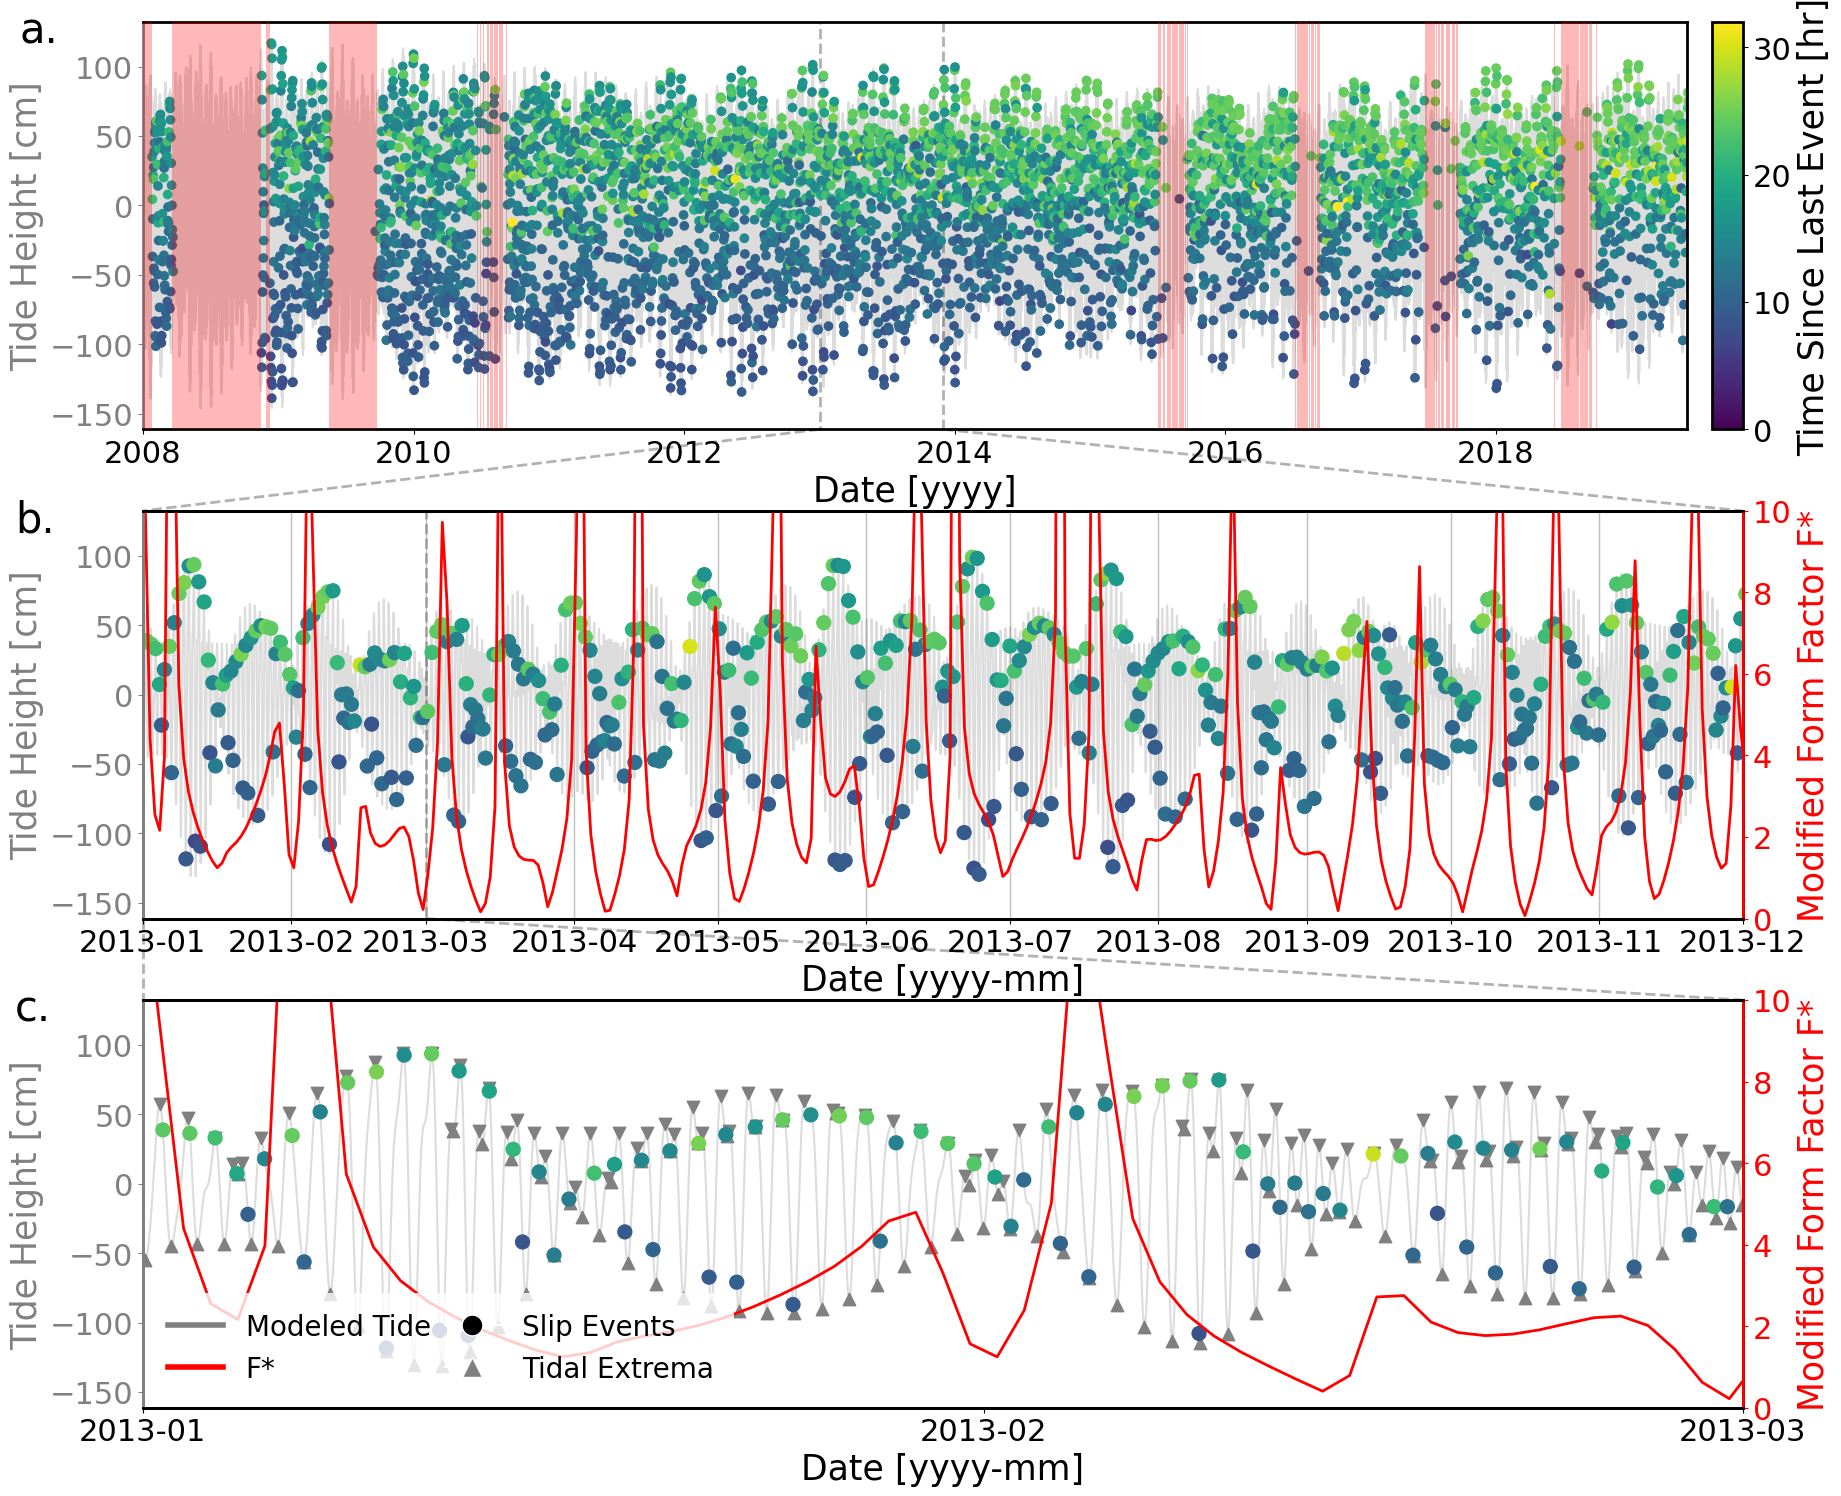

In [18]:
##########
# FIGURE 3
##########

# Plot tides to see trends with diurnal tides
def subplot(ax, place, dist, st, ed, triangles=False, ff=False):
    """Subplot for Figure 3. Plots tides and events colored by time since last event

    Parameters
    ----------
    ax : matplotlib.pyplot.axis
        Axis to plot on
    place : str
        Place tides are modeled at
    dist : dict
        Dict of high and low tides
    st : datetime.datetime
        Start time of panel
    ed : datetime.datetime
        End time of panel;
    triangles : bool, optional
        Flag to plot low and high tide triangles. Default is False.
    """
    ax.plot(dates_timeseries, ev_data[f"tides{place}"], zorder=0, color="gainsboro")
    if triangles:
        ax.scatter(
            dist["pk_date"], dist["pk_tide"], zorder=0, color="gray", marker="v", s=80
        )
        ax.scatter(
            dist["vly_date"], dist["vly_tide"], zorder=0, color="gray", marker="^", s=80
        )
    hr_since_last_ev = [
        (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
    ]
    masked_hr = np.ma.masked_where(np.array(hr_since_last_ev) > 200, ev_data["ev_time"])
    if not ff:
        cax = ax.scatter(
            masked_hr,
            ev_data[f"tide_event_time_{place}"],
            c=hr_since_last_ev,
            zorder=2,
            cmap="viridis",
            vmin=0,
            vmax=32,
        )
    if ff:
        cax = ax.scatter(
            masked_hr,
            ev_data[f"tide_event_time_{place}"],
            c=hr_since_last_ev,
            zorder=2,
            cmap="viridis",
            vmin=0,
            vmax=32,
            s=100,
        )

    if not ff:
        divider = make_axes_locatable(ax)
        cax_colorbar = divider.append_axes("right", size="2%", pad=0.25)
        plt.colorbar(cax, cax=cax_colorbar)
        cax_colorbar.tick_params(labelsize=22)
        cax_colorbar.set_ylabel("Time Since Last Event [hr]", size=25)
    ax.set_xlim(st, ed)
    # ax.set_xlim(datetime.datetime(2012,12,8),datetime.datetime(2013,5,20))
    ax.set_xlabel("Date [yyyy]", size=25)
    if ff:
        # Set x date format
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.set_xlabel("Date [yyyy-mm]", size=25)

        legend_elements = [
            Line2D([0], [0], color="gray", lw=4, label="Modeled Tide"),
            Line2D([0], [0], color="red", lw=4, label="F*"),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="Slip Events",
                markerfacecolor="black",
                markersize=15,
            ),
            Line2D(
                [0],
                [0],
                marker="^",
                color="w",
                label="Tidal Extrema",
                markerfacecolor="gray",
                markersize=15,
            ),
            # Patch(facecolor='red', edgecolor=None,alpha=0.1,
            #      label='No Data'),
        ]

        ax_form_factor = ax.twinx()
        # ax_form_factor.plot(dates_form_factor, semidiurnal, color="red", linewidth=2)
        # ax_form_factor.plot(dates_form_factor, diurnal, color="blue", linewidth=2)
        ax_form_factor.plot(dates_form_factor, form_factors, color="red", linewidth=2)
        ax_form_factor.set_ylabel("Modified Form Factor F*", size=25, color="red")
        ax_form_factor.set_ylim(0, 10)
        ax_form_factor.yaxis.set_tick_params(labelsize=22, colors="red")
        ax_form_factor.spines["right"].set_color("red")
        ax_form_factor.spines["left"].set_color("gray")

        if triangles:
            legend = ax_form_factor.legend(
                handles=legend_elements,
                loc="lower left",
                facecolor=(1, 1, 1, 0.8),
                fontsize=20,
                edgecolor="none",
                ncol=2,
                columnspacing=0.5,
            )
            legend.get_frame().set_boxstyle("Square")

    ax.set_ylabel("Tide Height [cm]", size=25, color="gray")
    ax.xaxis.set_tick_params(labelsize=22)
    ax.yaxis.set_tick_params(labelsize=22, colors="gray")
    ax.spines["left"].set_color("gray")

    for start, interval in zip(no_data["starts"][:], no_data["interval"][:]):
        start = datetime.datetime.strptime(start, "%Y-%m-%d %H:%M:%S")
        rect = plt.Rectangle(
            (start, -200), interval, 1000, facecolor="red", alpha=0.1, zorder=3
        )
        ax1.add_patch(rect)

    # ax.set_title(f'{place} Tide Reference',size=20)


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=[20, 18])
st = datetime.datetime(2007, 12, 1)
ed = datetime.datetime(2019, 6, 17)

st = datetime.datetime(2008, 1, 1)
ed = datetime.datetime(2019, 6, 1)

subplot(ax1, "gz05", dist_gz05, st, ed, triangles=False, ff=False)
st = datetime.datetime(2013, 1, 1)
ed = datetime.datetime(2013, 12, 1)
rect = plt.Rectangle(
    (st, -200),
    ed - st,
    1000,
    facecolor="none",
    zorder=0,
    alpha=0.3,
    edgecolor="black",
    linewidth=2,
    linestyle="--",
)
ax1.add_patch(rect)


# st = datetime.datetime(2015, 12, 3)
# ed = datetime.datetime(2015, 12, 11)

# Add vertical lines each month
for i in range(1, 13):
    ax2.axvline(
        datetime.datetime(2013, i, 1),
        color="gray",
        linestyle="-",
        linewidth=1,
        alpha=0.5,
    )

subplot(ax2, "gz05", dist_gz05, st, ed, triangles=False, ff=True)

zoom_effect01(
    ax1,
    ax2,
    mdates.date2num(st),
    mdates.date2num(ed),
    ec="black",
    lw=2,
    alpha=0.3,
    ls="--",
)

st = datetime.datetime(2013, 1, 1)
ed = datetime.datetime(2013, 3, 1)

rect = plt.Rectangle(
    (st, -200),
    ed - st,
    1000,
    facecolor="none",
    zorder=0,
    alpha=0.3,
    edgecolor="black",
    linewidth=2,
    linestyle="--",
)
ax2.add_patch(rect)
subplot(ax3, "gz05", dist_gz05, st, ed, triangles=True, ff=True)
# ax3 = ax2.twinx()
# ax3.plot(df["time"], df["dispEast"], color="red")
# ax3.plot(df["time"], df["disp"], color="red")
ax1.annotate("a.", (-0.08, 0.95), xycoords="axes fraction", fontsize=30)
ax2.annotate("b.", (-0.08, 0.95), xycoords="axes fraction", fontsize=30)
ax3.annotate("c.", (-0.08, 0.95), xycoords="axes fraction", fontsize=30)


zoom_effect01(
    ax2,
    ax3,
    mdates.date2num(st),
    mdates.date2num(ed),
    ec="black",
    lw=2,
    alpha=0.3,
    ls="--",
)


# Adjust layout to make subplots have the same width
plt.subplots_adjust(left=0.1, right=0.9)

# Align y-labels and colorbars
fig.align_labels()

plt.show()
fig.tight_layout()
fig.savefig("Figure3.png", dpi=300)

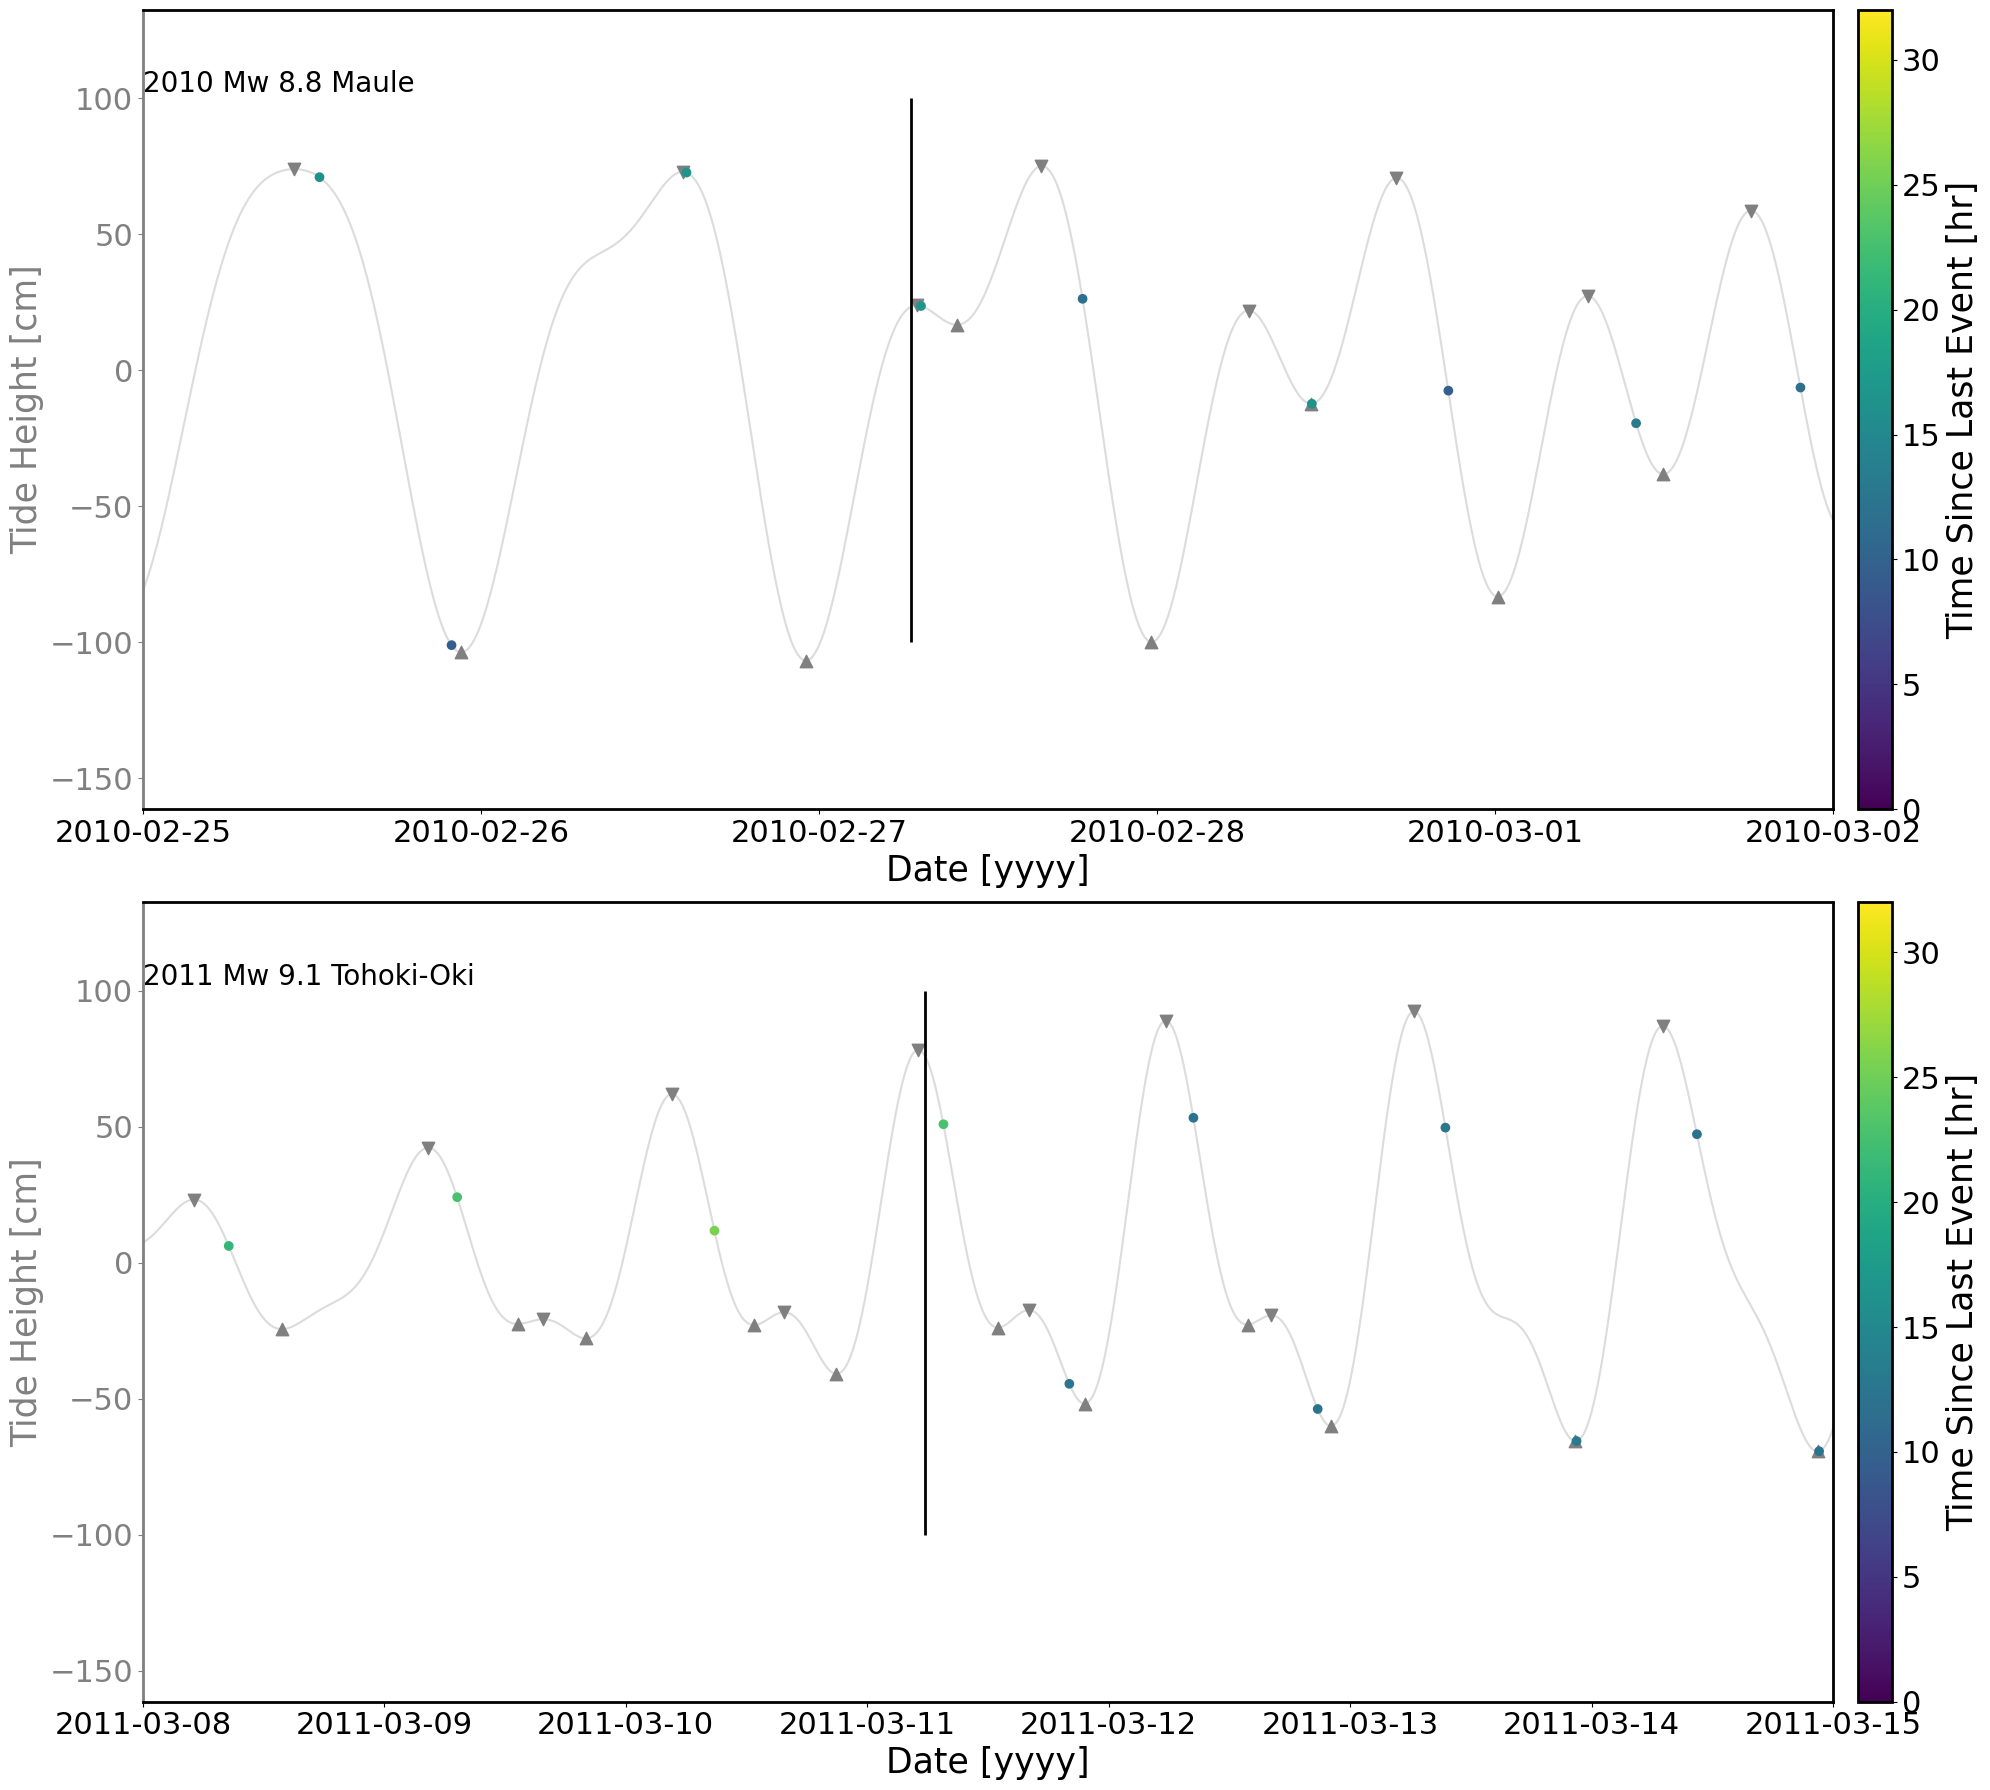

In [19]:
### INTERMEDIATE FIG (JAKE SLIP EVENTS)


def subplot_jake(ax, place, dist, st, ed, triangles=False, ff=False):
    """Subplot for Figure 3. Plots tides and events colored by time since last event

    Parameters
    ----------
    ax : matplotlib.pyplot.axis
        Axis to plot on
    place : str
        Place tides are modeled at
    dist : dict
        Dict of high and low tides
    st : datetime.datetime
        Start time of panel
    ed : datetime.datetime
        End time of panel;
    triangles : bool, optional
        Flag to plot low and high tide triangles. Default is False.
    """
    ax.plot(dates_timeseries, ev_data[f"tides{place}"], zorder=0, color="gainsboro")
    if triangles:
        ax.scatter(
            dist["pk_date"], dist["pk_tide"], zorder=0, color="gray", marker="v", s=80
        )
        ax.scatter(
            dist["vly_date"], dist["vly_tide"], zorder=0, color="gray", marker="^", s=80
        )
    hr_since_last_ev = [
        (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
    ]
    masked_hr = np.ma.masked_where(np.array(hr_since_last_ev) > 200, ev_data["ev_time"])
    if not ff:
        cax = ax.scatter(
            masked_hr,
            ev_data[f"tide_event_time_{place}"],
            c=hr_since_last_ev,
            zorder=2,
            cmap="viridis",
            vmin=0,
            vmax=32,
        )
    if ff:
        cax = ax.scatter(
            masked_hr,
            ev_data[f"tide_event_time_{place}"],
            c=hr_since_last_ev,
            zorder=2,
            cmap="viridis",
            vmin=0,
            vmax=32,
            s=100,
        )

    if not ff:
        divider = make_axes_locatable(ax)
        cax_colorbar = divider.append_axes("right", size="2%", pad=0.25)
        plt.colorbar(cax, cax=cax_colorbar)
        cax_colorbar.tick_params(labelsize=22)
        cax_colorbar.set_ylabel("Time Since Last Event [hr]", size=25)
    ax.set_xlim(st, ed)
    # ax.set_xlim(datetime.datetime(2012,12,8),datetime.datetime(2013,5,20))
    ax.set_xlabel("Date [yyyy]", size=25)
    if ff:
        # Set x date format
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.set_xlabel("Date [yyyy-mm]", size=25)

        legend_elements = [
            Line2D([0], [0], color="gray", lw=4, label="Modeled Tide"),
            Line2D([0], [0], color="red", lw=4, label="F*"),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="Slip Events",
                markerfacecolor="black",
                markersize=15,
            ),
            Line2D(
                [0],
                [0],
                marker="^",
                color="w",
                label="Tidal Extrema",
                markerfacecolor="gray",
                markersize=15,
            ),
            # Patch(facecolor='red', edgecolor=None,alpha=0.1,
            #      label='No Data'),
        ]

        ax_form_factor = ax.twinx()
        # ax_form_factor.plot(dates_form_factor, semidiurnal, color="red", linewidth=2)
        # ax_form_factor.plot(dates_form_factor, diurnal, color="blue", linewidth=2)
        ax_form_factor.plot(dates_form_factor, form_factors, color="red", linewidth=2)
        ax_form_factor.set_ylabel("Modified Form Factor F*", size=25, color="red")
        ax_form_factor.set_ylim(0, 10)
        ax_form_factor.yaxis.set_tick_params(labelsize=22, colors="red")
        ax_form_factor.spines["right"].set_color("red")
        ax_form_factor.spines["left"].set_color("gray")

        if triangles:
            legend = ax_form_factor.legend(
                handles=legend_elements,
                loc="lower left",
                facecolor=(1, 1, 1, 0.8),
                fontsize=20,
                edgecolor="none",
                ncol=2,
                columnspacing=0.5,
            )
            legend.get_frame().set_boxstyle("Square")

    ax.set_ylabel("Tide Height [cm]", size=25, color="gray")
    ax.xaxis.set_tick_params(labelsize=22)
    ax.yaxis.set_tick_params(labelsize=22, colors="gray")
    ax.spines["left"].set_color("gray")
    # ax.set_title(f'{place} Tide Reference',size=20)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=[20, 18])

st = datetime.datetime(2010, 2, 25)
ed = datetime.datetime(2010, 3, 2)
subplot_jake(ax1, "gz05", dist_gz05, st, ed, triangles=True, ff=False)
ax1.vlines(
    datetime.datetime(2010, 2, 27, 6, 34),
    -100,
    100,
    color="black",
    linewidth=2,
    zorder=0,
)
ax1.text(
    datetime.datetime(2010, 2, 25),
    100,
    "2010 Mw 8.8 Maule",
    color="black",
    size=20,
    ha="left",
    va="bottom",
)


st = datetime.datetime(2011, 3, 8)
ed = datetime.datetime(2011, 3, 15)

subplot_jake(ax2, "gz05", dist_gz05, st, ed, triangles=True, ff=False)
ax2.vlines(
    datetime.datetime(2011, 3, 11, 5, 46),
    -100,
    100,
    color="black",
    linewidth=2,
    zorder=0,
)

ax2.text(
    datetime.datetime(2011, 3, 8),
    100,
    "2011 Mw 9.1 Tohoki-Oki",
    color="black",
    size=20,
    ha="left",
    va="bottom",
)


# Adjust layout to make subplots have the same width
plt.subplots_adjust(left=0.1, right=0.9)

# Align y-labels and colorbars
fig.align_labels()
fig.tight_layout()

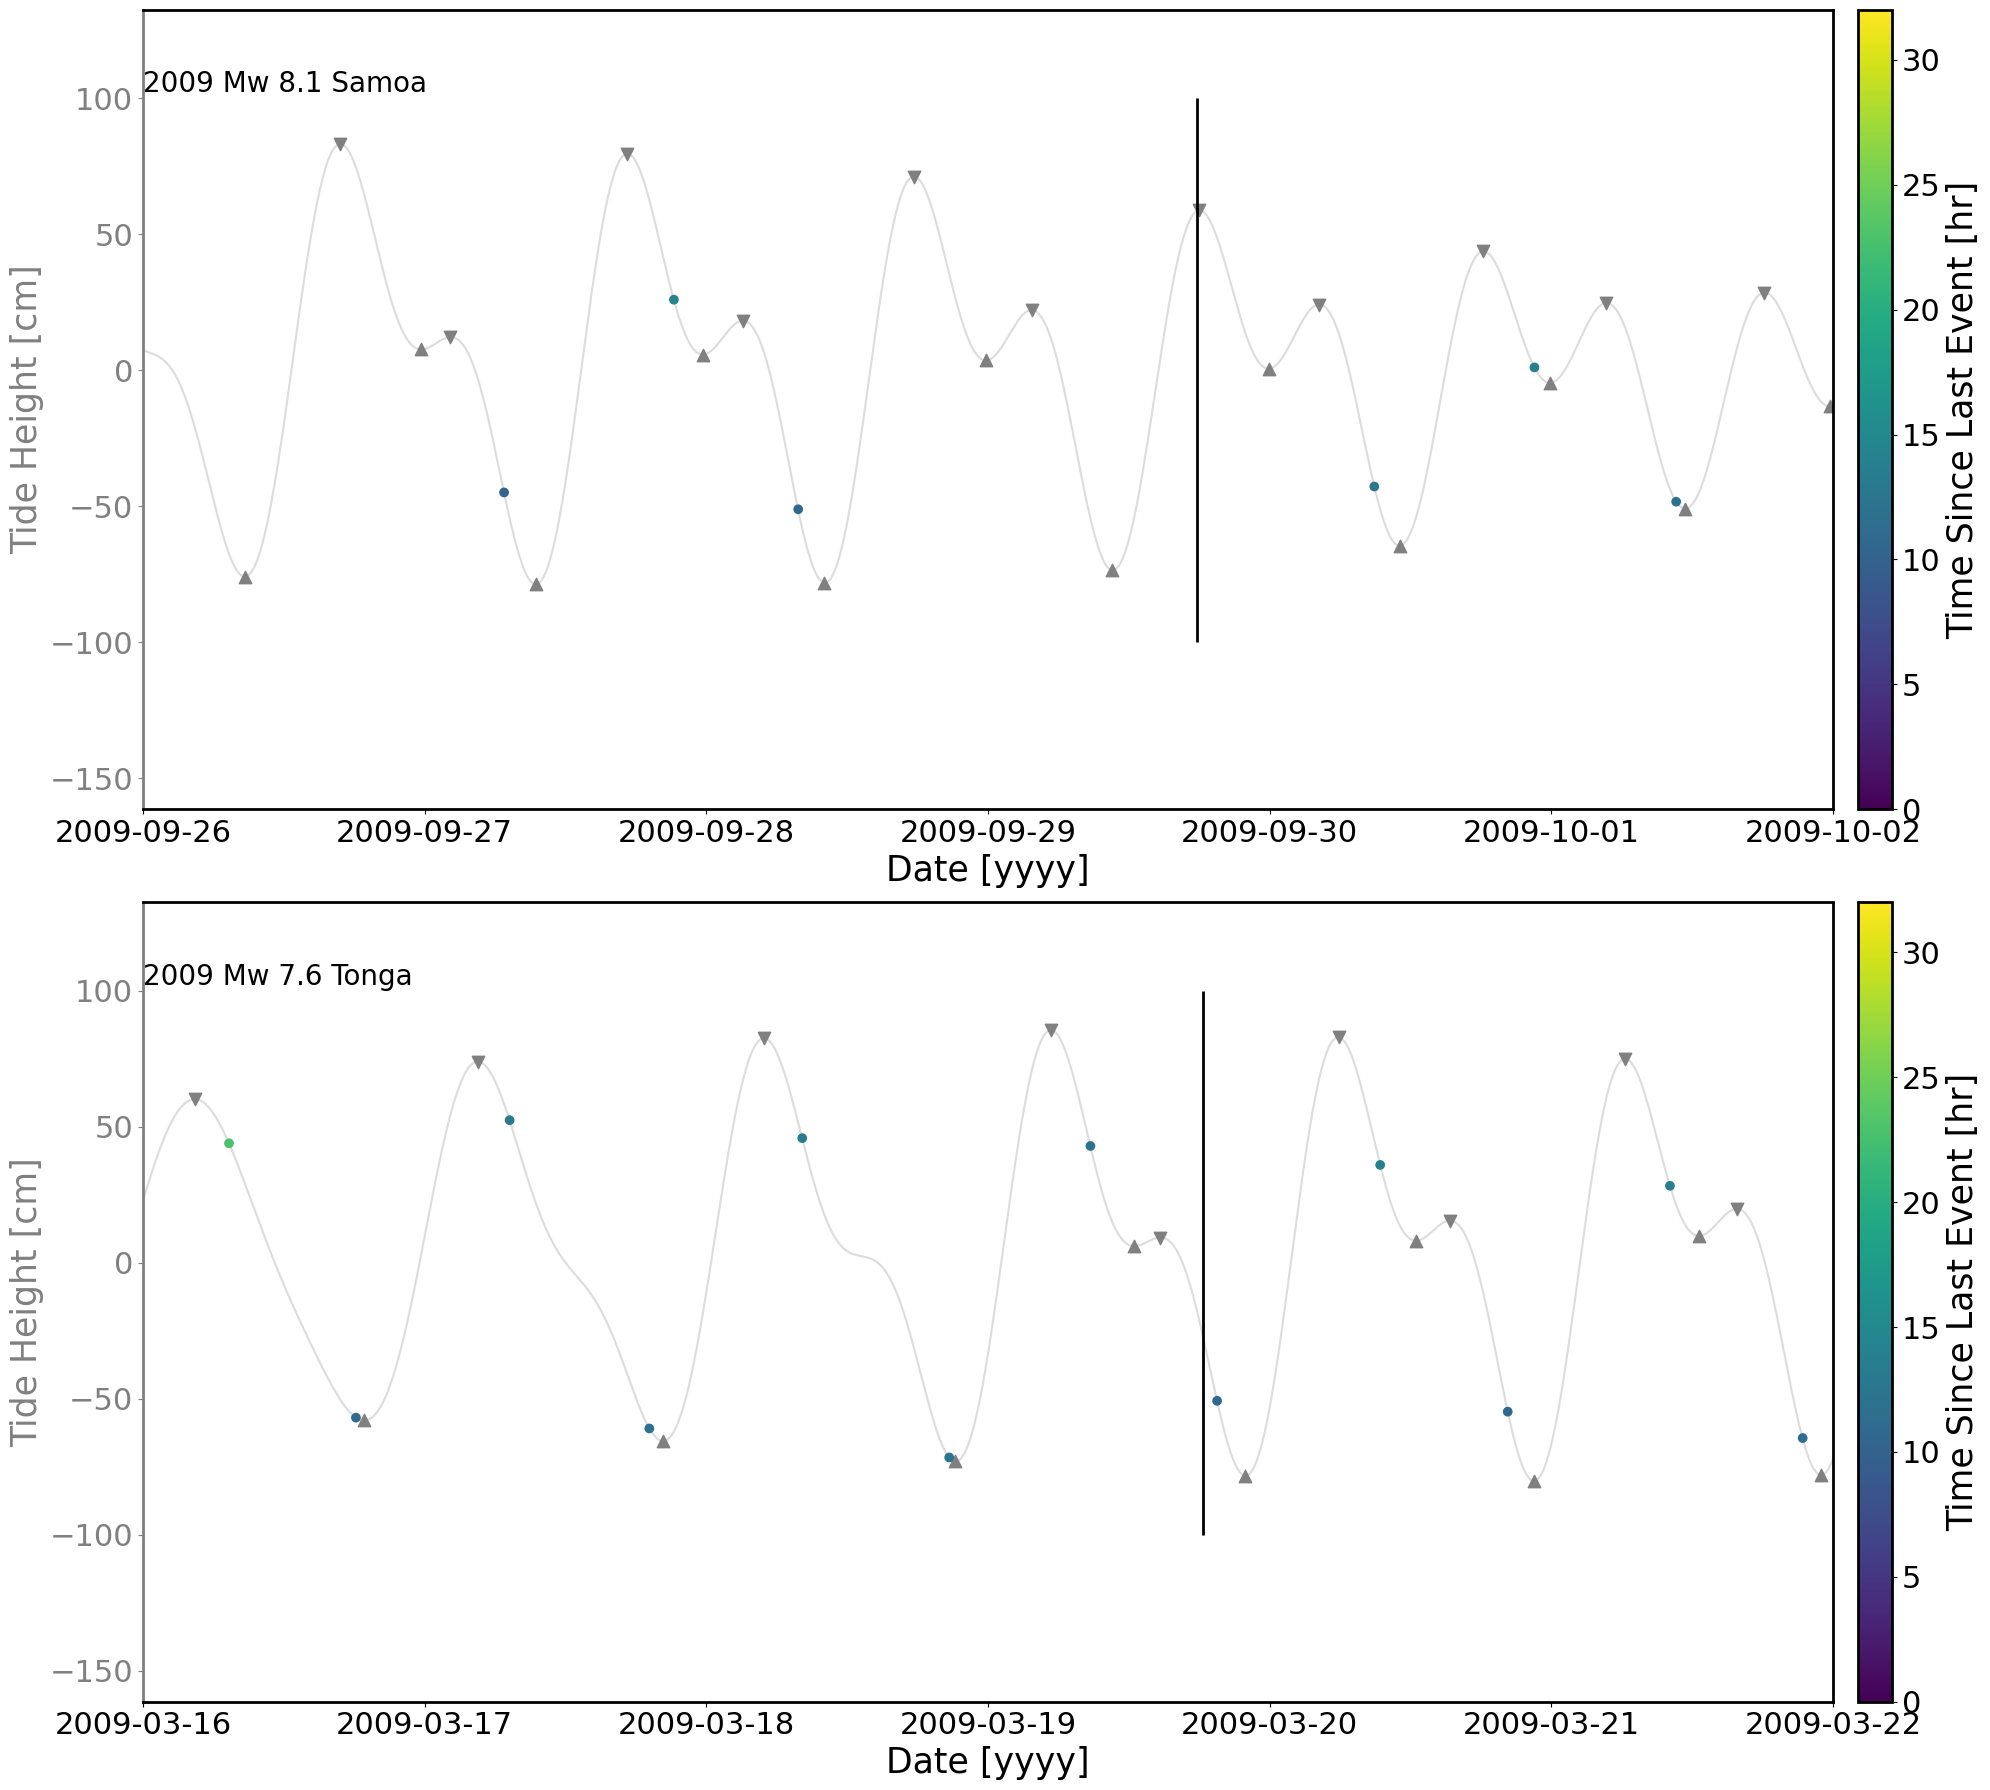

In [20]:
### INTERMEDIATE FIG (JAKE SLIP EVENTS)


def subplot_jake(ax, place, dist, st, ed, triangles=False, ff=False):
    """Subplot for Figure 3. Plots tides and events colored by time since last event

    Parameters
    ----------
    ax : matplotlib.pyplot.axis
        Axis to plot on
    place : str
        Place tides are modeled at
    dist : dict
        Dict of high and low tides
    st : datetime.datetime
        Start time of panel
    ed : datetime.datetime
        End time of panel;
    triangles : bool, optional
        Flag to plot low and high tide triangles. Default is False.
    """
    ax.plot(dates_timeseries, ev_data[f"tides{place}"], zorder=0, color="gainsboro")
    if triangles:
        ax.scatter(
            dist["pk_date"], dist["pk_tide"], zorder=0, color="gray", marker="v", s=80
        )
        ax.scatter(
            dist["vly_date"], dist["vly_tide"], zorder=0, color="gray", marker="^", s=80
        )
    hr_since_last_ev = [
        (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
    ]
    masked_hr = np.ma.masked_where(np.array(hr_since_last_ev) > 200, ev_data["ev_time"])
    if not ff:
        cax = ax.scatter(
            masked_hr,
            ev_data[f"tide_event_time_{place}"],
            c=hr_since_last_ev,
            zorder=2,
            cmap="viridis",
            vmin=0,
            vmax=32,
        )
    if ff:
        cax = ax.scatter(
            masked_hr,
            ev_data[f"tide_event_time_{place}"],
            c=hr_since_last_ev,
            zorder=2,
            cmap="viridis",
            vmin=0,
            vmax=32,
            s=100,
        )

    if not ff:
        divider = make_axes_locatable(ax)
        cax_colorbar = divider.append_axes("right", size="2%", pad=0.25)
        plt.colorbar(cax, cax=cax_colorbar)
        cax_colorbar.tick_params(labelsize=22)
        cax_colorbar.set_ylabel("Time Since Last Event [hr]", size=25)
    ax.set_xlim(st, ed)
    # ax.set_xlim(datetime.datetime(2012,12,8),datetime.datetime(2013,5,20))
    ax.set_xlabel("Date [yyyy]", size=25)
    if ff:
        # Set x date format
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.set_xlabel("Date [yyyy-mm]", size=25)

        legend_elements = [
            Line2D([0], [0], color="gray", lw=4, label="Modeled Tide"),
            Line2D([0], [0], color="red", lw=4, label="F*"),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="Slip Events",
                markerfacecolor="black",
                markersize=15,
            ),
            Line2D(
                [0],
                [0],
                marker="^",
                color="w",
                label="Tidal Extrema",
                markerfacecolor="gray",
                markersize=15,
            ),
            # Patch(facecolor='red', edgecolor=None,alpha=0.1,
            #      label='No Data'),
        ]

        ax_form_factor = ax.twinx()
        # ax_form_factor.plot(dates_form_factor, semidiurnal, color="red", linewidth=2)
        # ax_form_factor.plot(dates_form_factor, diurnal, color="blue", linewidth=2)
        ax_form_factor.plot(dates_form_factor, form_factors, color="red", linewidth=2)
        ax_form_factor.set_ylabel("Modified Form Factor F*", size=25, color="red")
        ax_form_factor.set_ylim(0, 10)
        ax_form_factor.yaxis.set_tick_params(labelsize=22, colors="red")
        ax_form_factor.spines["right"].set_color("red")
        ax_form_factor.spines["left"].set_color("gray")

        if triangles:
            legend = ax_form_factor.legend(
                handles=legend_elements,
                loc="lower left",
                facecolor=(1, 1, 1, 0.8),
                fontsize=20,
                edgecolor="none",
                ncol=2,
                columnspacing=0.5,
            )
            legend.get_frame().set_boxstyle("Square")

    ax.set_ylabel("Tide Height [cm]", size=25, color="gray")
    ax.xaxis.set_tick_params(labelsize=22)
    ax.yaxis.set_tick_params(labelsize=22, colors="gray")
    ax.spines["left"].set_color("gray")
    # ax.set_title(f'{place} Tide Reference',size=20)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=[20, 18])

st = datetime.datetime(2009, 9, 26)
ed = datetime.datetime(2009, 10, 2)
subplot_jake(ax1, "gz05", dist_gz05, st, ed, triangles=True, ff=False)
ax1.vlines(
    datetime.datetime(2009, 9, 29, 17, 48),
    -100,
    100,
    color="black",
    linewidth=2,
    zorder=0,
)
ax1.text(
    datetime.datetime(2009, 9, 26),
    100,
    "2009 Mw 8.1 Samoa",
    color="black",
    size=20,
    ha="left",
    va="bottom",
)


st = datetime.datetime(2009, 3, 16)
ed = datetime.datetime(2009, 3, 22)

subplot_jake(ax2, "gz05", dist_gz05, st, ed, triangles=True, ff=False)
ax2.vlines(
    datetime.datetime(2009, 3, 19, 18, 17),
    -100,
    100,
    color="black",
    linewidth=2,
    zorder=0,
)

ax2.text(
    datetime.datetime(2009, 3, 16),
    100,
    "2009 Mw 7.6 Tonga",
    color="black",
    size=20,
    ha="left",
    va="bottom",
)


# Adjust layout to make subplots have the same width
plt.subplots_adjust(left=0.1, right=0.9)

# Align y-labels and colorbars
fig.align_labels()
fig.tight_layout()

In [21]:
# Start rolling average plot cells
# Find time since last event for all skipped low tides
time_since_last_event_low_pk = []
time_to_next_event_low_pk = []

events = np.ma.masked_where(
    np.array(dist_gz05["high_closers"]) == 1, ev_data["ev_time"]
)
events = np.ma.compressed(events)
tide_low = np.ma.masked_where(
    np.array(dist_gz05["high_closers"]) == 1, ev_data["tide_event_time_gz05"]
)
tide_low = np.ma.compressed(tide_low)

for i, valley in enumerate(dist_gz05["vly_date"]):
    closest_event = min(
        events,
        key=lambda d: abs(datetime.datetime.strptime(d, "%Y-%m-%d %H:%M:%S") - valley),
    )
    if datetime.datetime.strptime(closest_event, "%Y-%m-%d %H:%M:%S") > valley:
        closest_event = events[np.where(events == closest_event)[0] - 1][0]
    time_since_last_event_low_pk.append(
        valley - datetime.datetime.strptime(closest_event, "%Y-%m-%d %H:%M:%S")
    )

    closest_event = min(
        events,
        key=lambda d: abs(datetime.datetime.strptime(d, "%Y-%m-%d %H:%M:%S") - valley),
    )
    if datetime.datetime.strptime(closest_event, "%Y-%m-%d %H:%M:%S") < valley:
        try:
            closest_event = events[np.where(events == closest_event)[0] + 1][0]
        except IndexError:
            pass
    time_to_next_event_low_pk.append(
        datetime.datetime.strptime(closest_event, "%Y-%m-%d %H:%M:%S") - valley
    )

In [22]:
def rolling_average(
    window,
    slide_len,
    time_since_last_event_low_pk,
    time_to_next_event_low_pk,
    dist_gz05,
    ev_data,
    no_data,
):
    """Rolling average of slip events.

    Parameters
    ----------
    window : int
        Days to average over
    slide_len : int
        Days to slide window
    time_since_last_event_low_pk : list
        Times since last event
    time_to_next_event_low_pk : list
        Time to next event
    dist_gz05 : dict
        Dict of high and low tides
    ev_data : dict
        Dict of event data
    no_data : dict
        Dict of no data times
    """
    # Compute rolling average of skipped low slips

    time_since_low_hr = [a.total_seconds() / 3600 for a in time_since_last_event_low_pk]
    time_to_low_hr = [a.total_seconds() / 3600 for a in time_to_next_event_low_pk]

    mask = []
    for ts, tt in zip(time_since_low_hr, time_to_low_hr):
        if ts < 6 or tt < 6:
            mask.append(1)
        else:
            mask.append(0)

    masked_low_skips = np.ma.masked_where(mask, dist_gz05["vly_date"])
    masked_low_skips = np.ma.compressed(masked_low_skips)

    dates_timeseries_avg = []
    initial_time = datetime.datetime.strptime(
        "2007-12-01 00:00:00", "%Y-%m-%d %H:%M:%S"
    )

    time_to_append = window  # Days
    slide = slide_len  # Days

    # assert time_to_append % slide == 0
    interval = int(time_to_append // slide)  # MUST BE AN INTEGER

    rng = int(12 * 365 // slide)  # Range of times
    for i in range(rng):
        dates_timeseries_avg.append(initial_time + datetime.timedelta(days=slide * i))

    skips = []
    skip_starts = []
    skip_ends = []
    skip_middles = []
    tot_slips = []
    spacings = []
    mean_disp = []

    for i, date in enumerate(dates_timeseries_avg):
        if i > interval:
            interval_start = dates_timeseries_avg[i - interval]
            interval_end = date

            # print(interval_start,interval_end)
            last_ev = datetime.datetime.strptime(
                ev_data["ev_time"].iloc[-1], "%Y-%m-%d %H:%M:%S"
            )
            first_ev = datetime.datetime.strptime(
                ev_data["ev_time"].iloc[0], "%Y-%m-%d %H:%M:%S"
            )
            stop = False
            for start, end in zip(no_data["starts"], no_data["ends"]):
                start = datetime.datetime.strptime(start, "%Y-%m-%d %H:%M:%S")
                end = datetime.datetime.strptime(end, "%Y-%m-%d %H:%M:%S")

                # Check that interval does not include gaps in data or start before 1st event or end after last event
                # if (interval_start > start and interval_start < end) or (interval_end > start and interval_end < end) \
                #    or (interval_start < end and interval_end > start) or (interval_start < start and interval_end > start) \
                #        or interval_start < first_ev \
                #        or interval_end > last_ev:
                #    stop = True

                if (
                    (interval_start < end and interval_end > start)
                    or interval_start < first_ev
                    or interval_end > last_ev
                ):
                    stop = True

            if not stop:
                # Number of total events
                slip = 0
                for event in ev_data["ev_time"]:
                    event = datetime.datetime.strptime(event, "%Y-%m-%d %H:%M:%S")
                    if event > interval_start and event < interval_end:
                        slip += 1

                # Number of low skips
                skip = 0
                for date_low in masked_low_skips:
                    if date_low > interval_start and date_low < interval_end:
                        skip += 1

                # Avg Event spacing
                spacing = 0
                counter = 0
                time_since = [
                    (a.days * 24 * 3600 + a.seconds) / 3600
                    for a in ev_data["time_since_last_ev"]
                ]
                for f, event in enumerate(ev_data["ev_time"]):
                    event = datetime.datetime.strptime(event, "%Y-%m-%d %H:%M:%S")
                    if event > interval_start and event < interval_end:
                        spacing += time_since[f]
                        counter += 1
                try:
                    spacing = spacing / counter
                except ZeroDivisionError:
                    spacing = np.nan
                # Avg Event amplitude

            else:
                skip = np.nan
                slip = np.nan
                spacing = np.nan

            skip_starts.append(interval_start)
            skip_ends.append(interval_end)
            skip_middles.append(interval_start + (interval_end - interval_start) / 2)
            skips.append(skip)
            tot_slips.append(slip)
            spacings.append(spacing)
            mean_disp.append(0)

    return skip_starts, skip_ends, skip_middles, skips, tot_slips, spacings, mean_disp


def annotation(ax, x1, x2, y1, y2, text):
    """Draws an annotated bracket."""
    xs = [x1, x1, x2, x2]
    ys = [y1, y2, y2, y1]
    ax.plot(xs, ys, "k-")
    ax.text((x2 - x1) / 2 + x1, y2 + 0.1, text, ha="center", va="bottom", fontsize=18)

In [23]:
slide = 1
rolling_avg_dicts = []
for window in [3, 27, 45]:
    # for window in [45]:
    skip_starts, skip_ends, skip_middles, skips, tot_slips, spacings, mean_z_slip = (
        rolling_average(
            window,
            slide,
            time_since_last_event_low_pk,
            time_to_next_event_low_pk,
            dist_gz05,
            ev_data,
            no_data,
        )
    )
    # Save as dict
    rolling_avg_dict = {
        "skip_starts": skip_starts,
        "skip_ends": skip_ends,
        "skip_middles": skip_middles,
        "skips": skips,
        "tot_slips": tot_slips,
        "spacings": spacings,
        "mean_disps": mean_z_slip,
    }
    rolling_avg_dicts.append(rolling_avg_dict)

In [24]:
# Plotting function
def plot_rolling_avg_section(
    fig,
    ax1,
    ax3,
    window,
    slide_len,
    skip_starts,
    skip_ends,
    skip_middles,
    skips,
    tot_slips,
    spacings,
    mean_disps,
):
    # Skipped slips by number of slips in xx period
    ax2 = ax1.twinx()
    (
        ax1.plot(
            dates_timeseries, ev_data["tidesgz05"], zorder=1, color="gray", alpha=0.4
        ),
    )
    for start, interval in zip(no_data["starts"][:], no_data["interval"][:]):
        start = datetime.datetime.strptime(start, "%Y-%m-%d %H:%M:%S")
        rect = plt.Rectangle(
            (start, -200), interval, 1000, facecolor="red", alpha=0.2, zorder=3
        )
        ax1.add_patch(rect)

    ax1.set_xlim(datetime.datetime(2008, 1, 1), datetime.datetime(2019, 6, 1))
    ax1.set_ylim(-120, 130)

    xerr = [(end - start) // 2 for start, end in zip(skip_starts, skip_ends)]
    norm_slips = [i / window for i in tot_slips]

    ax2.errorbar(skip_middles, norm_slips, xerr=xerr, fmt=".", zorder=2, color="black")
    ax2.scatter(
        skip_middles,
        norm_slips,
        s=30,
        color="black",
        zorder=10,
    )
    # ax2.plot(skip_middles, tot_slips, color='blue'

    timestamps = [a.timestamp() for a in skip_middles]

    compressed_tot_slips = np.ma.masked_invalid(tot_slips)
    compressed_timestamps = np.ma.masked_where(
        np.ma.getmask(compressed_tot_slips), timestamps
    )
    compressed_tot_slips = np.ma.compressed(compressed_tot_slips)
    compressed_timestamps = np.ma.compressed(compressed_timestamps)

    coef = np.polyfit(compressed_timestamps, compressed_tot_slips, 1)
    print(coef)
    lst_sqrs_fit = np.poly1d(coef)
    print(lst_sqrs_fit[1])

    datetimes = [datetime.datetime.fromtimestamp(a) for a in compressed_timestamps]
    # ax2.plot(datetimes, lst_sqrs_fit(compressed_timestamps),color='blue',zorder=3)

    # Just a line so manually extract slope
    delta_y = (
        lst_sqrs_fit(compressed_timestamps)[-1] - lst_sqrs_fit(compressed_timestamps)[0]
    )
    delta_x = datetimes[-1] - datetimes[0]

    print(delta_y, delta_x)
    slope = delta_y / delta_x.total_seconds() * 3600 * 24 * 365
    print(slope)  # Slips / year
    ax1.yaxis.set_label_position("right")
    ax1.yaxis.tick_right()
    ax2.yaxis.set_label_position("left")
    ax2.yaxis.tick_left()
    ax1.set_xlabel("Date [yyyy]", size=28)
    ax1.set_ylabel("Tide Height [cm]", size=28, color="gray")
    ax.spines["left"].set_color("gray")
    ax2.set_ylabel("Slips/Day", size=28, color="black")
    ax1.xaxis.set_tick_params(labelsize=22)
    ax1.yaxis.set_tick_params(labelsize=22, colors="gray")
    ax1.spines["right"].set_color("gray")
    ax2.spines["right"].set_color("gray")
    ax2.yaxis.set_tick_params(labelsize=22, colors="black")
    # ax2.spines['left'].set_color('red')

    ax4 = ax3.twinx()
    (
        ax3.plot(
            dates_timeseries, ev_data["tidesgz05"], zorder=1, color="gray", alpha=0.4
        ),
    )
    for start, interval in zip(no_data["starts"][:], no_data["interval"][:]):
        start = datetime.datetime.strptime(start, "%Y-%m-%d %H:%M:%S")
        rect = plt.Rectangle(
            (start, -200), interval, 1000, facecolor="black", alpha=0.2, zorder=3
        )
        ax3.add_patch(rect)

    st3 = datetime.datetime(2014, 1, 1)
    ed3 = datetime.datetime(2015, 6, 1)

    ax3.set_xlim(st3, ed3)
    # ax3.set_xlim(datetime.datetime(2008,12,8),datetime.datetime(2009,7,1))
    ax3.set_ylim(-155, 130)

    xerr = [(end - start) // 2 for start, end in zip(skip_starts, skip_ends)]
    # Segmet skipmiddles and norm_slips by date
    mask = [start > st3 and end < ed3 for start, end in zip(skip_middles, skip_ends)]
    skip_middles = np.array(skip_middles)[mask]
    norm_slips = np.array(norm_slips)[mask]
    xerr = np.array(xerr)[mask]

    ax4.errorbar(skip_middles, norm_slips, xerr=xerr, fmt=".", zorder=2, color="black")
    ax4.scatter(
        skip_middles,
        norm_slips,
        s=30,
        color="black",
        zorder=10,
    )

    ax3.yaxis.set_label_position("right")
    ax3.yaxis.tick_right()
    ax4.yaxis.set_label_position("left")
    ax4.yaxis.tick_left()
    ax3.set_xlabel("Date [yyyy-mm]", size=28)
    ax3.set_ylabel("Tide Height [cm]", size=28, color="gray")
    ax3.spines["right"].set_color("gray")
    ax3.spines["right"].set_color("gray")
    ax4.set_ylabel("Slips/Day", size=28, color="black")
    ax3.xaxis.set_tick_params(labelsize=22)
    ax3.yaxis.set_tick_params(labelsize=22, colors="gray")
    ax4.yaxis.set_tick_params(labelsize=22, colors="black")

    ssa_time = datetime.timedelta(days=182.63)
    ssa_start = datetime.datetime(2014, 3, 1)
    annotation(ax1, ssa_start, ssa_start + ssa_time, 92, 96, "$S_{sa}$")

    mm_time = datetime.timedelta(days=27.55)
    mm_start = datetime.datetime(2014, 6, 11)
    annotation(ax3, mm_start, mm_start + mm_time, 94, 98, "$M_{m}$")

27.578274760383387 Days, Power = 0.1641924298386055
14.765651727677042 Days, Power = 0.07736563256816044
13.67987321711569 Days, Power = 0.07090007635223255
[-6.90558492e-08  1.60973513e+02]
-6.905584918421701e-08
-25.500253428255817 4274 days, 0:00:00
-2.1777240293199283
185.0198412698413 Days, Power = 0.3035246063613893


/tmp/ipykernel_41162/2985102190.py:192: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


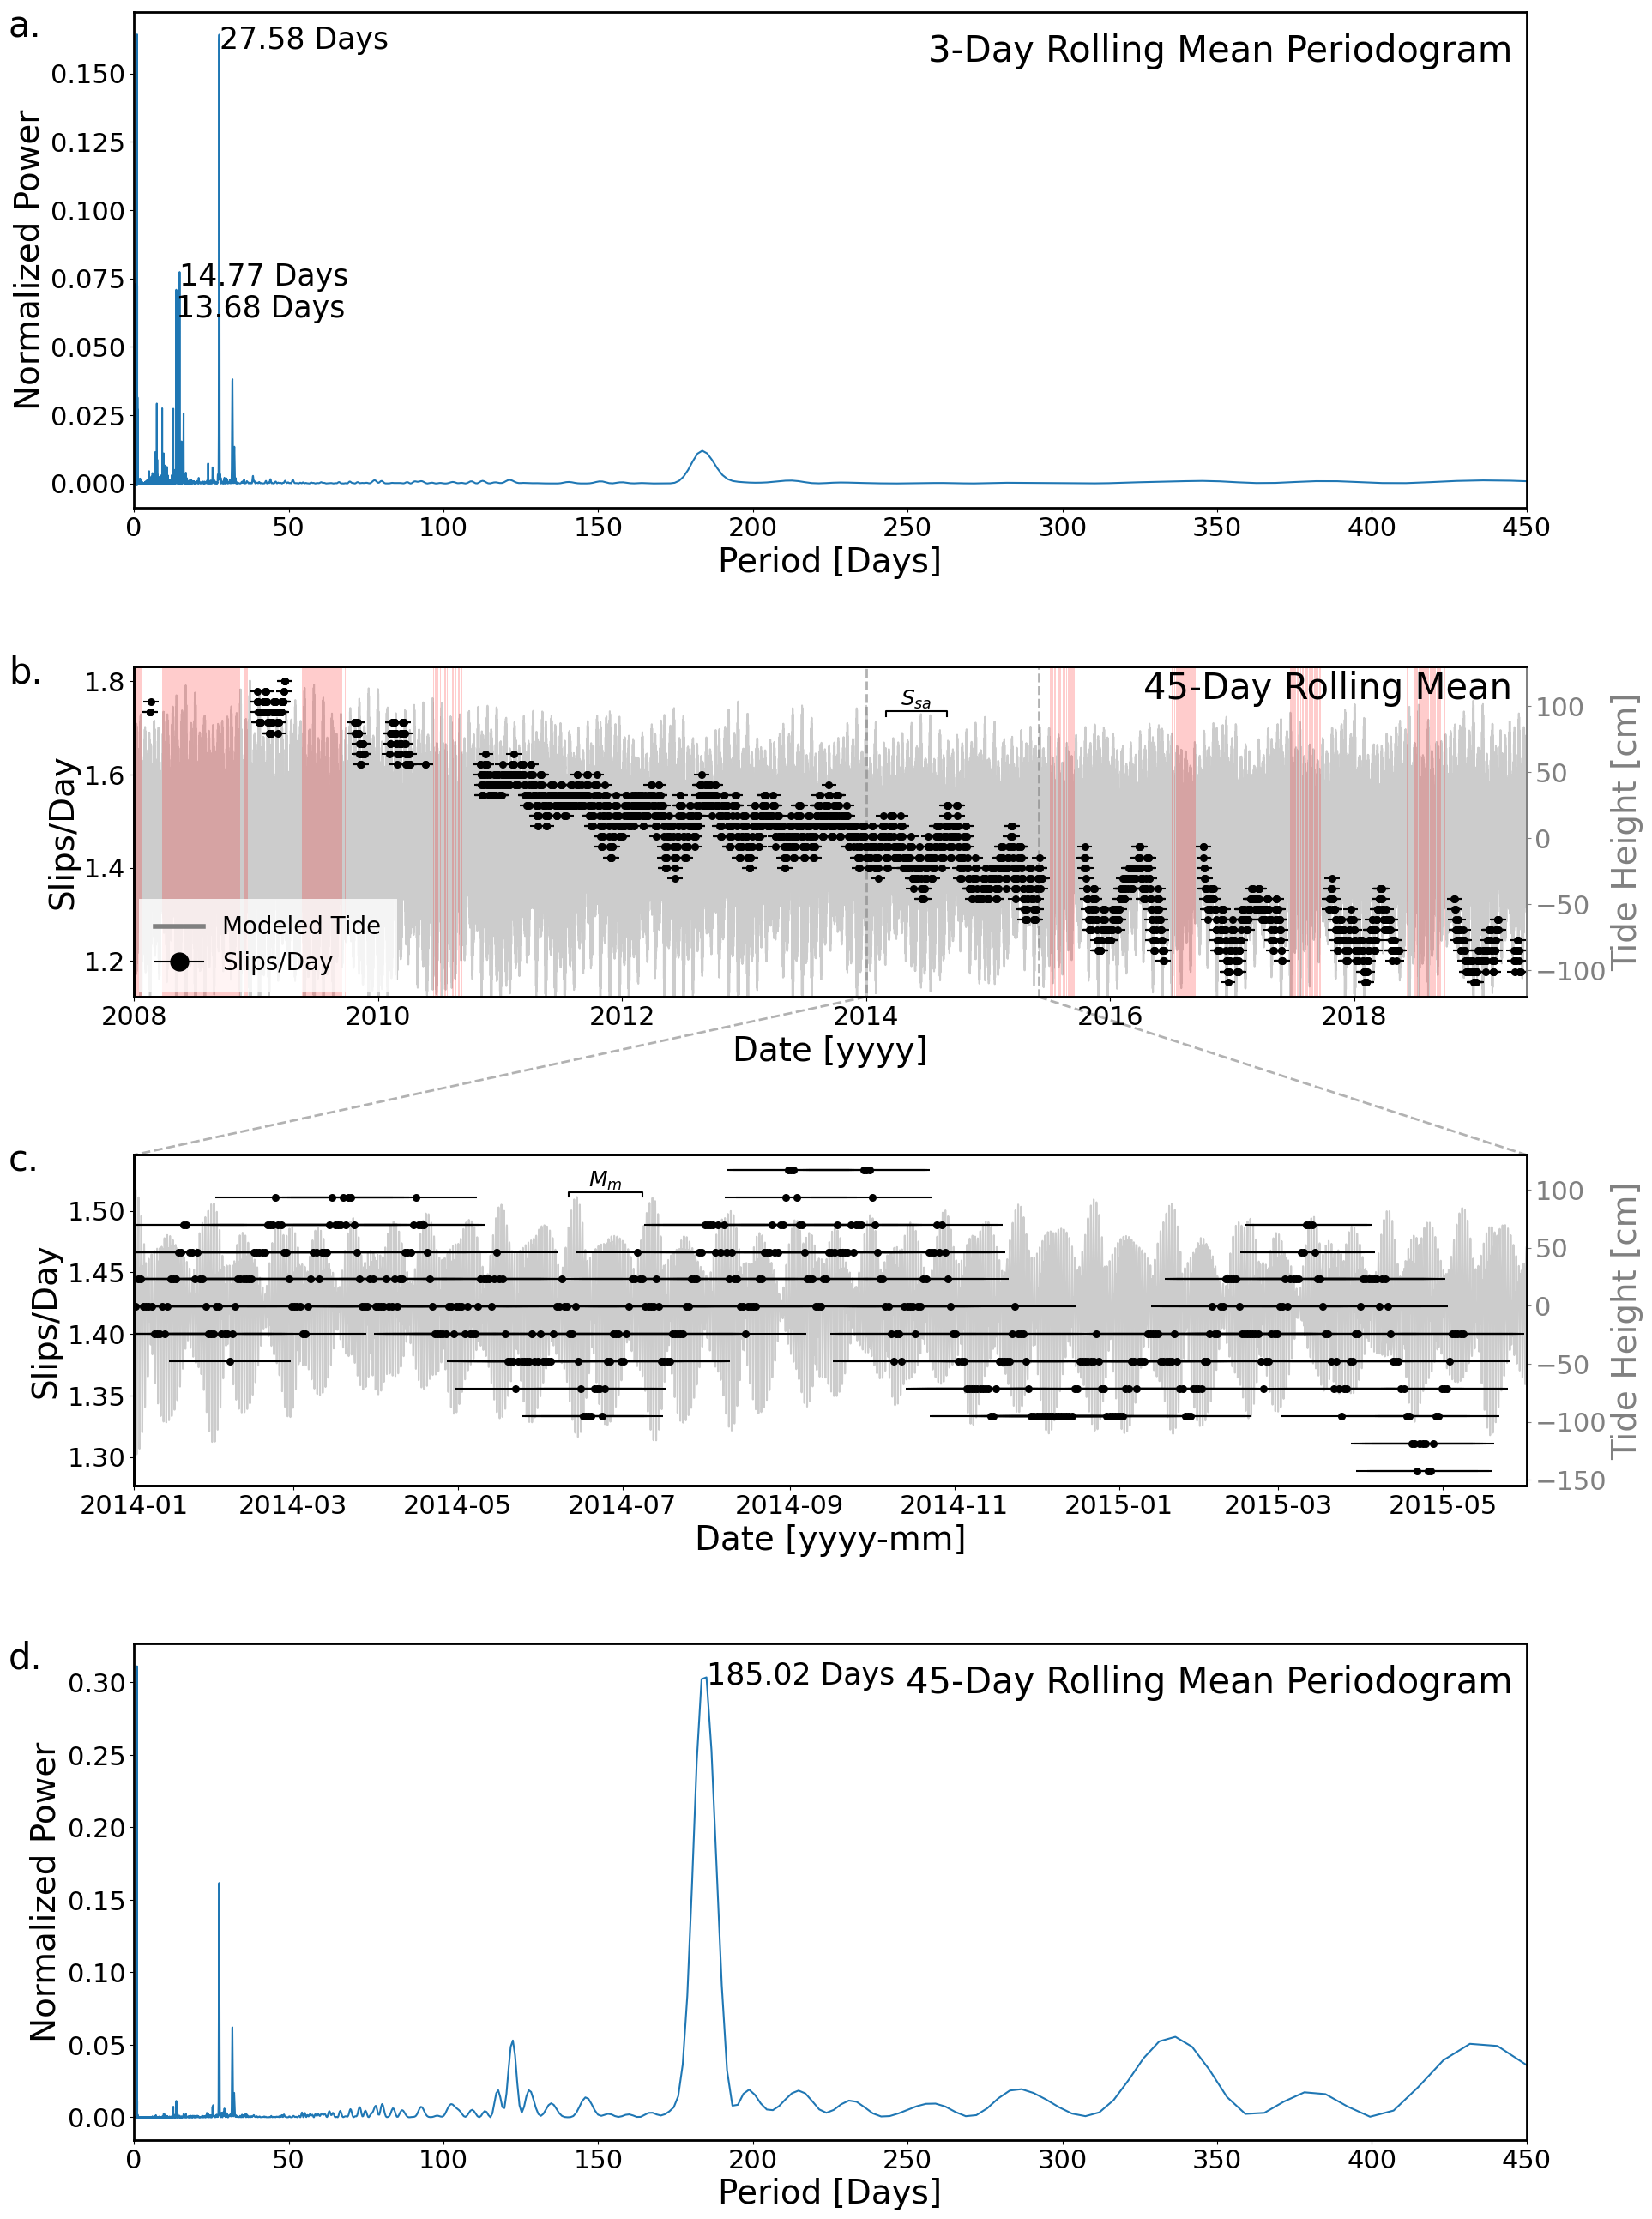

In [25]:
#########
# Figure 4
#########

SEC_TO_DAY = 3600 * 24
SEC_TO_HR = 3600
xlim = 450

viridis = mpl.colormaps["viridis"].resampled(20)
# Add window to rolling avg dict
for i, window in enumerate([3, 27, 45]):
    # for i, window in enumerate([]):
    rolling_avg_dicts[i]["window"] = window

fig = plt.figure(
    figsize=[20, 26],
    constrained_layout=True,
)
gs = mpl.gridspec.GridSpec(
    4, 2, figure=fig, width_ratios=[0.9, 0.03], height_ratios=[1.5, 1, 1, 1.5]
)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[3, 0])

rolling_avg_dict = rolling_avg_dicts[0]
skip_starts = rolling_avg_dict["skip_starts"]
skip_ends = rolling_avg_dict["skip_ends"]
skip_middles = rolling_avg_dict["skip_middles"]
skips = rolling_avg_dict["skips"]
tot_slips = rolling_avg_dict["tot_slips"]
spacings = rolling_avg_dict["spacings"]
window = rolling_avg_dict["window"]
mean_disps = rolling_avg_dict["mean_disps"]

# Lomb Scargle
dates_as_sec = [a.timestamp() for a in skip_middles]
tot_slips_masked = np.ma.masked_array(tot_slips, mask=np.invert(~np.isnan(tot_slips)))
dates_as_sec_masked = np.ma.masked_array(
    dates_as_sec, mask=np.invert(~np.isnan(tot_slips))
)
tot_slips_masked = np.ma.compressed(tot_slips_masked)
dates_as_sec_masked = np.ma.compressed(dates_as_sec_masked)
tot_slips_detrended = scipy.signal.detrend(tot_slips_masked)

# Spectrogram of rolling avg slips using lomb scargle
frequency, power = LombScargle(dates_as_sec_masked, tot_slips_detrended).autopower()

pks = scipy.signal.find_peaks(power[:10000], height=0.06)[0]
# ax.plot(frequency[pks], power[pks], 'ro')
period = 1 / frequency / SEC_TO_DAY  # Days
ax1.plot(period, power)
ax1.set_xlabel("Period [Days]", fontsize=28)
ax1.set_ylabel("Normalized Power", fontsize=28)
ax1.xaxis.set_tick_params(labelsize=22)
ax1.yaxis.set_tick_params(labelsize=22)
ax1.set_xlim(0, xlim)
ax1.text(
    0.99,
    0.9,
    "3-Day Rolling Mean Periodogram",
    fontsize=30,
    transform=ax1.transAxes,
    horizontalalignment="right",
)

for pk, pwr in zip(period[pks], power[pks]):
    if pk < xlim:
        if pk > 0:
            print(f"{pk} Days, Power = {pwr}")
            if pk < 14:
                ax1.text(pk + 0.001e-5, pwr - 0.01, f"{pk:.2f} Days", fontsize=25)
            else:
                ax1.text(pk + 0.001e-5, pwr - 0.005, f"{pk:.2f} Days", fontsize=25)

        else:
            print(f"{pk} Hours, Power = {pwr}")
            ax1.text(pk + 0.001e-5, pwr, f"{pk:.2f} Hours", fontsize=25)


rolling_avg_dict = rolling_avg_dicts[2]
skip_starts = rolling_avg_dict["skip_starts"]
skip_ends = rolling_avg_dict["skip_ends"]
skip_middles = rolling_avg_dict["skip_middles"]
skips = rolling_avg_dict["skips"]
tot_slips = rolling_avg_dict["tot_slips"]
spacings = rolling_avg_dict["spacings"]
window = rolling_avg_dict["window"]
mean_disps = rolling_avg_dict["mean_disps"]
plot_rolling_avg_section(
    fig,
    ax2,
    ax3,
    window,
    slide,
    skip_starts,
    skip_ends,
    skip_middles,
    skips,
    tot_slips,
    spacings,
    mean_disps,
)
ax2.text(
    0.99,
    0.9,
    "45-Day Rolling Mean",
    fontsize=30,
    transform=ax2.transAxes,
    horizontalalignment="right",
)
# Lomb Scargle
dates_as_sec = [a.timestamp() for a in skip_middles]
tot_slips_masked = np.ma.masked_array(tot_slips, mask=np.invert(~np.isnan(tot_slips)))
dates_as_sec_masked = np.ma.masked_array(
    dates_as_sec, mask=np.invert(~np.isnan(tot_slips))
)
tot_slips_masked = np.ma.compressed(tot_slips_masked)
dates_as_sec_masked = np.ma.compressed(dates_as_sec_masked)
tot_slips_detrended = scipy.signal.detrend(tot_slips_masked)

# Spectrogram of rolling avg slips using lomb scargle
frequency, power = LombScargle(dates_as_sec_masked, tot_slips_detrended).autopower()

pks = scipy.signal.find_peaks(power[:10000], height=0.06)[0]
# ax.plot(frequency[pks], power[pks], 'ro')
period = 1 / frequency / SEC_TO_DAY  # Days
ax4.plot(period, power)
ax4.set_xlabel("Period [Days]", fontsize=28)
ax4.set_ylabel("Normalized Power", fontsize=28)
ax4.xaxis.set_tick_params(labelsize=22)
ax4.yaxis.set_tick_params(labelsize=22)
ax4.set_xlim(0, xlim)
# ax.set_ylim(0,0.1)

for pk, pwr in zip(period[pks], power[pks]):
    if pk < xlim and pwr > 0.2:
        if pk > 0:
            print(f"{pk} Days, Power = {pwr}")
            if pk < 14:
                ax4.text(pk + 0.001e-5, pwr - 0.005, f"{pk:.2f} Days", fontsize=25)
            else:
                ax4.text(pk + 0.001e-5, pwr - 0.005, f"{pk:.2f} Days", fontsize=25)

        else:
            print(f"{pk} Hours, Power = {pwr}")
            ax4.text(pk + 0.001e-5, pwr, f"{pk:.2f} Hours", fontsize=25)
ax4.text(
    0.99,
    0.9,
    "45-Day Rolling Mean Periodogram",
    fontsize=30,
    transform=ax4.transAxes,
    horizontalalignment="right",
)
ax1.annotate("a.", (-0.09, 0.95), xycoords="axes fraction", fontsize=30)
ax2.annotate("b.", (-0.09, 0.95), xycoords="axes fraction", fontsize=30)
ax3.annotate("c.", (-0.09, 0.95), xycoords="axes fraction", fontsize=30)
ax4.annotate("d.", (-0.09, 0.95), xycoords="axes fraction", fontsize=30)

st3 = datetime.datetime(2014, 1, 1)
ed3 = datetime.datetime(2015, 6, 1)

# Adds patch and zoom effect
rect = plt.Rectangle(
    (st3, -200),
    ed3 - st3,
    1000,
    facecolor="none",
    zorder=0,
    alpha=0.3,
    edgecolor="black",
    linewidth=2,
    linestyle="--",
)
ax2.add_patch(rect)


zoom_effect01(
    ax2,
    ax3,
    mdates.date2num(st3),
    mdates.date2num(ed3),
    ec="black",
    lw=2,
    alpha=0.3,
    ls="--",
)


fig.tight_layout()

legend_elements = [
    Line2D([0], [0], color="gray", lw=4, label="Modeled Tide"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        label="Slips/Day",
        markerfacecolor="black",
        markersize=15,
    ),
    # Patch(facecolor='red', edgecolor=None,alpha=0.1,
    #      label='No Data'),
]

legend = ax2.legend(
    handles=legend_elements,
    loc="lower left",
    facecolor=(1, 1, 1, 0.8),
    fontsize=20,
    edgecolor="none",
    ncol=1,
    columnspacing=0.5,
)
legend.get_frame().set_boxstyle("Square")

fig.savefig("Figure4.png", dpi=300)

In [26]:
def subplotS3(ax, place, dist, st, ed, color, triangles=False):
    """Subplot for Figure 3. Plots tides and events colored by time since last event

    Parameters
    ----------
    ax : matplotlib.pyplot.axis
        Axis to plot on
    place : str
        Place tides are modeled at
    dist : dict
        Dict of high and low tides
    st : datetime.datetime
        Start time of panel
    ed : datetime.datetime
        End time of panel;
    triangles : bool, optional
        Flag to plot low and high tide triangles. Default is False.
    """
    if triangles:
        ax.scatter(dist["pk_date"], dist["pk_tide"], zorder=0, color="gray", marker="v")
        ax.scatter(
            dist["vly_date"], dist["vly_tide"], zorder=0, color="gray", marker="^"
        )
    hr_since_last_ev = [
        (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
    ]
    masked_hr = np.ma.masked_where(np.array(hr_since_last_ev) > 32, ev_data["ev_time"])
    cax = ax.scatter(
        masked_hr,
        ev_data[f"tide_event_time_{place}"],
        c=hr_since_last_ev,
        zorder=2,
        cmap="viridis",
        vmin=0,
        vmax=32,
    )
    ax.set_xlim(st, ed)
    # ax.set_xlim(datetime.datetime(2012,12,8),datetime.datetime(2013,5,20))
    ax.set_xlabel("Date [yyyy]", size=22)
    if triangles:
        ax.set_xlabel("Date [yyyy-mm-dd]", size=22)

    ax.set_ylabel("Tide Height [cm]", size=22)
    ax.xaxis.set_tick_params(labelsize=18)
    ax.yaxis.set_tick_params(labelsize=18)

    for start, interval in zip(no_data["starts"][:], no_data["interval"][:]):
        start = datetime.datetime.strptime(start, "%Y-%m-%d %H:%M:%S")
        rect = plt.Rectangle(
            (start, -200), interval, 1000, facecolor="black", alpha=0.1, zorder=3
        )
        ax1.add_patch(rect)
    return cax

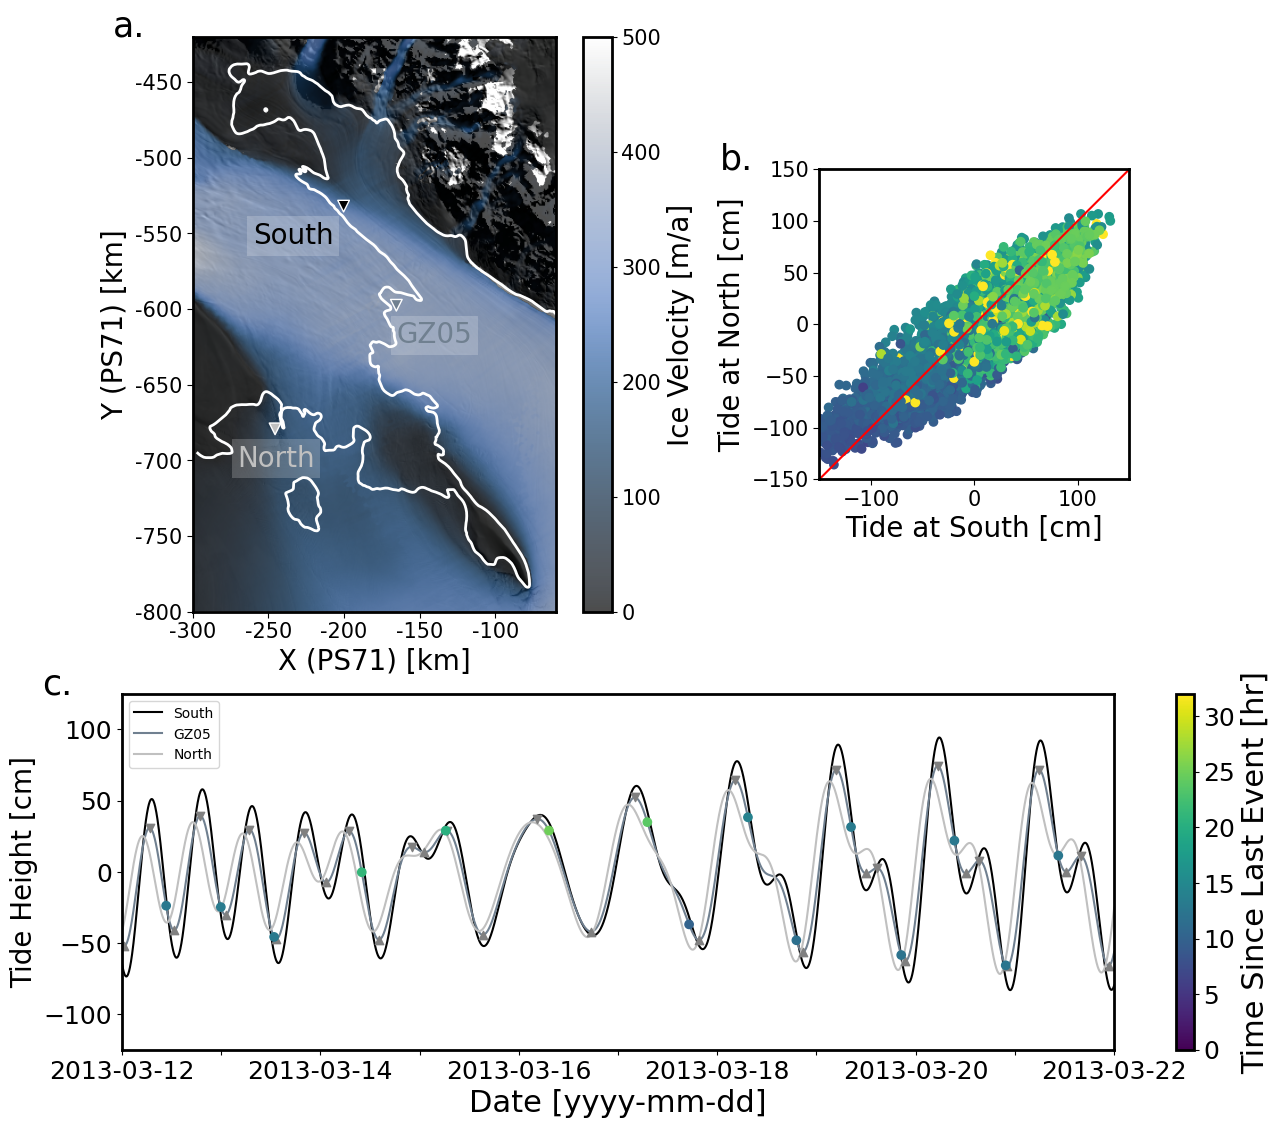

In [27]:
##########
# Figure S3
##########

# Overall size based on map aspect
fig = plt.figure(figsize=[16, 16])
gs = mpl.gridspec.GridSpec(6, 6, wspace=2, hspace=0.6)
ax0 = fig.add_subplot(gs[0:3, 0:3])
ax1 = fig.add_subplot(gs[0:3, 3:5], aspect="equal")
ax2 = fig.add_subplot(gs[3:5, 0:6])
cbar_ax = fig.add_subplot(gs[0:3, 2])
cbar_ax.axis("off")

# Map
oslo = Colormap("crameri:oslo").to_mpl()
ax0.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
v = ax0.imshow(
    vel_mag,
    extent=(x_min_v, x_max_v, y_min_v, y_max_v),
    cmap=oslo,
    vmax=500,
    vmin=0,
    alpha=0.7,
)
for i, shape in enumerate(sf.shapes(bbox=bbox)):
    if i > 0:
        points = shape.points
        # Only get points within bounding box
        inbox = inBox(points, bbox)
        line = LineString(inbox)
        plot_line(line, ax=ax0, add_points=False, color="white")
x_min, x_max = bbox[0], bbox[2]
y_min, y_max = bbox[1], bbox[3]
ax0.set_xlim(x_min, x_max)
ax0.set_ylim(y_min, y_max)
KM_SCALE = 1e3
ticks_x = ticker.FuncFormatter(lambda x, pos: "{0:g}".format(x / KM_SCALE))
ax0.xaxis.set_major_formatter(ticks_x)
ticks_y = ticker.FuncFormatter(lambda x, pos: "{0:g}".format(x / KM_SCALE))
ax0.yaxis.set_major_formatter(ticks_y)
ax0.set_xlabel("X (PS71) [km]", size=20)
ax0.set_ylabel("Y (PS71) [km]", size=20)
ax0.tick_params(labelsize=15)
ax0.tick_params(size=4)
# ax.set_facecolor("black")
cbarv = fig.colorbar(v)
cbarv.ax.tick_params(labelsize=15)
cbarv.ax.set_ylabel("Ice Velocity [m/a]", size=20)

lats = [-84.2986, y_north, y_south]
lons = [-164.5206, x_north, x_south]
places = ["gz05", "North", "South"]

x, y = ll2xy(lons, lats)
colors = ["slategray", "silver", "black"]
ax0.scatter(x, y, s=70, color=colors, marker="v", edgecolors="white")
t = ax0.text(x[0], y[0] - 25000, "GZ05", color=colors[0], size=20)
t.set_bbox(dict(facecolor="white", alpha=0.2, linewidth=0))
t = ax0.text(x[1] - 25000, y[1] - 25000, "North", color=colors[1], size=20)
t.set_bbox(dict(facecolor="white", alpha=0.2, linewidth=0))
t = ax0.text(x[2] - 60000, y[2] - 25000, "South", color=colors[2], size=20)
t.set_bbox(dict(facecolor="white", alpha=0.2, linewidth=0))


# Scatterplot
hr_since_last_ev = [
    (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
]
masked_hr = np.ma.masked_where(np.array(hr_since_last_ev) > 32, ev_data["ev_time"])
cax = ax1.scatter(
    ev_data["tide_event_time_South"],
    ev_data["tide_event_time_North"],
    c=hr_since_last_ev,
    zorder=2,
    cmap="viridis",
    vmin=0,
    vmax=32,
)

ax1.set_xlabel("Tide at South [cm]", size=20)
ax1.set_ylabel("Tide at North [cm]", size=20)
ax1.set_xlim(-150, 150)
ax1.set_ylim(-150, 150)
x = np.arange(-150, 250, 150)
y = np.arange(-150, 250, 150)
ax1.plot(y, x, "red")
ax1.tick_params(labelsize=15)
ax1.tick_params(size=4)

st = datetime.datetime(2013, 3, 12)
ed = datetime.datetime(2013, 3, 22)

ax2.plot(
    dates_timeseries, ev_data["tidesSouth"], zorder=0, color=colors[2], label="South"
)
ax2.plot(
    dates_timeseries, ev_data["tidesgz05"], zorder=0, color=colors[0], label="GZ05"
)
ax2.plot(
    dates_timeseries, ev_data["tidesNorth"], zorder=0, color=colors[1], label="North"
)

cax = subplotS3(ax2, "gz05", dist_gz05, st, ed, colors[0], triangles=True)
# cax = subplotS3(ax2, "North", dist_North, st, ed, colors[1], triangles=True)
# cax = subplotS3(ax2, "South", dist_South, st, ed, colors[2], triangles=True)
cbar = plt.colorbar(cax)
cbar.set_label("Time Since Last Event [hr]", size=22)
cbar.ax.tick_params(labelsize=18)

ax2.set_ylabel("Tide Height [cm]", size=20)
for i, label in enumerate(ax2.get_xticklabels()):
    label.set_visible(i % 2 == 0)
ax2.legend()
ax2.set_ylim(-125, 125)

ax0.annotate("a.", (-0.22, 1.00), xycoords="axes fraction", fontsize=25)
ax1.annotate("b.", (-0.32, 1.00), xycoords="axes fraction", fontsize=25)
ax2.annotate("c.", (-0.08, 1.00), xycoords="axes fraction", fontsize=25)
fig.savefig("FigureS3.png", dpi=300)

[-4.58661604e-09  1.07283306e+01]
-4.58661603574803e-09
-1.7103601276089258 4316 days, 0:00:00
-0.14464352330334984
27.578274760383387 Days, Power = 0.1641924298386055
14.765651727677042 Days, Power = 0.07736563256816044
13.67987321711569 Days, Power = 0.07090007635223255


/tmp/ipykernel_41162/1581734906.py:125: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


[-4.14756976e-08  9.67066371e+01]
-4.1475697642662366e-08
-15.380383185991306 4292 days, 0:00:00
-1.3079776008589996
184.206008583691 Days, Power = 0.3060478324187821


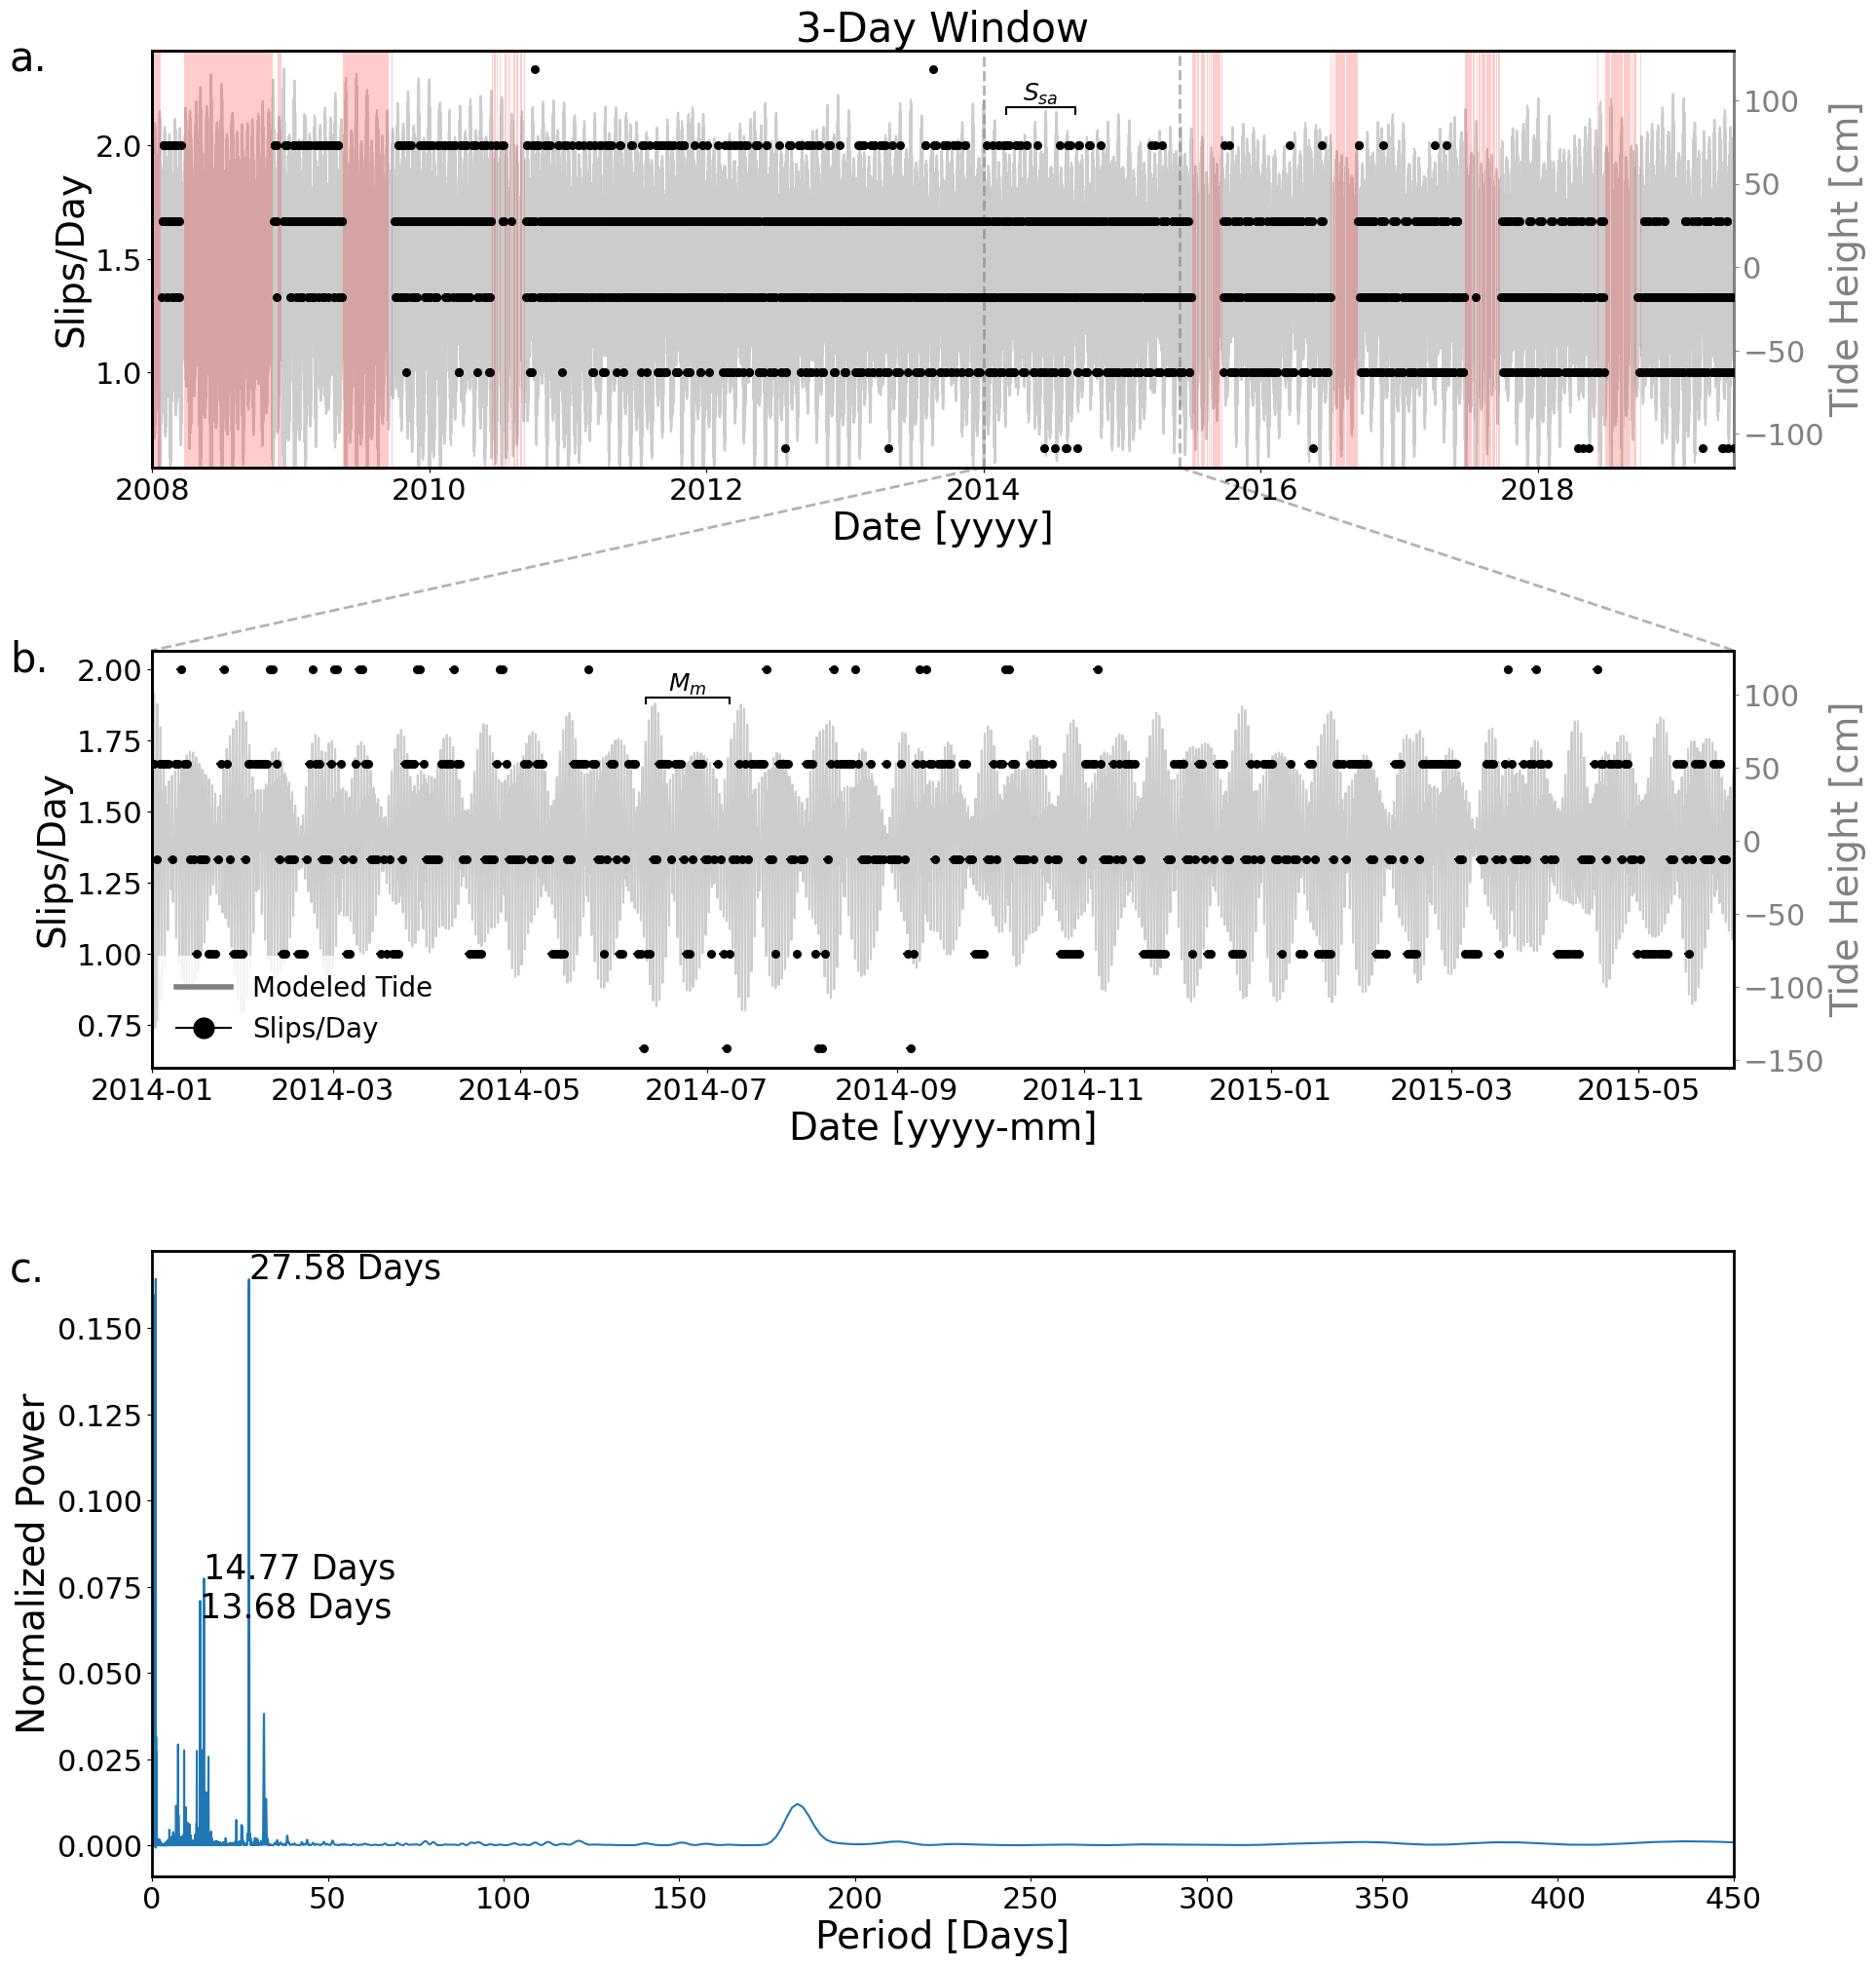

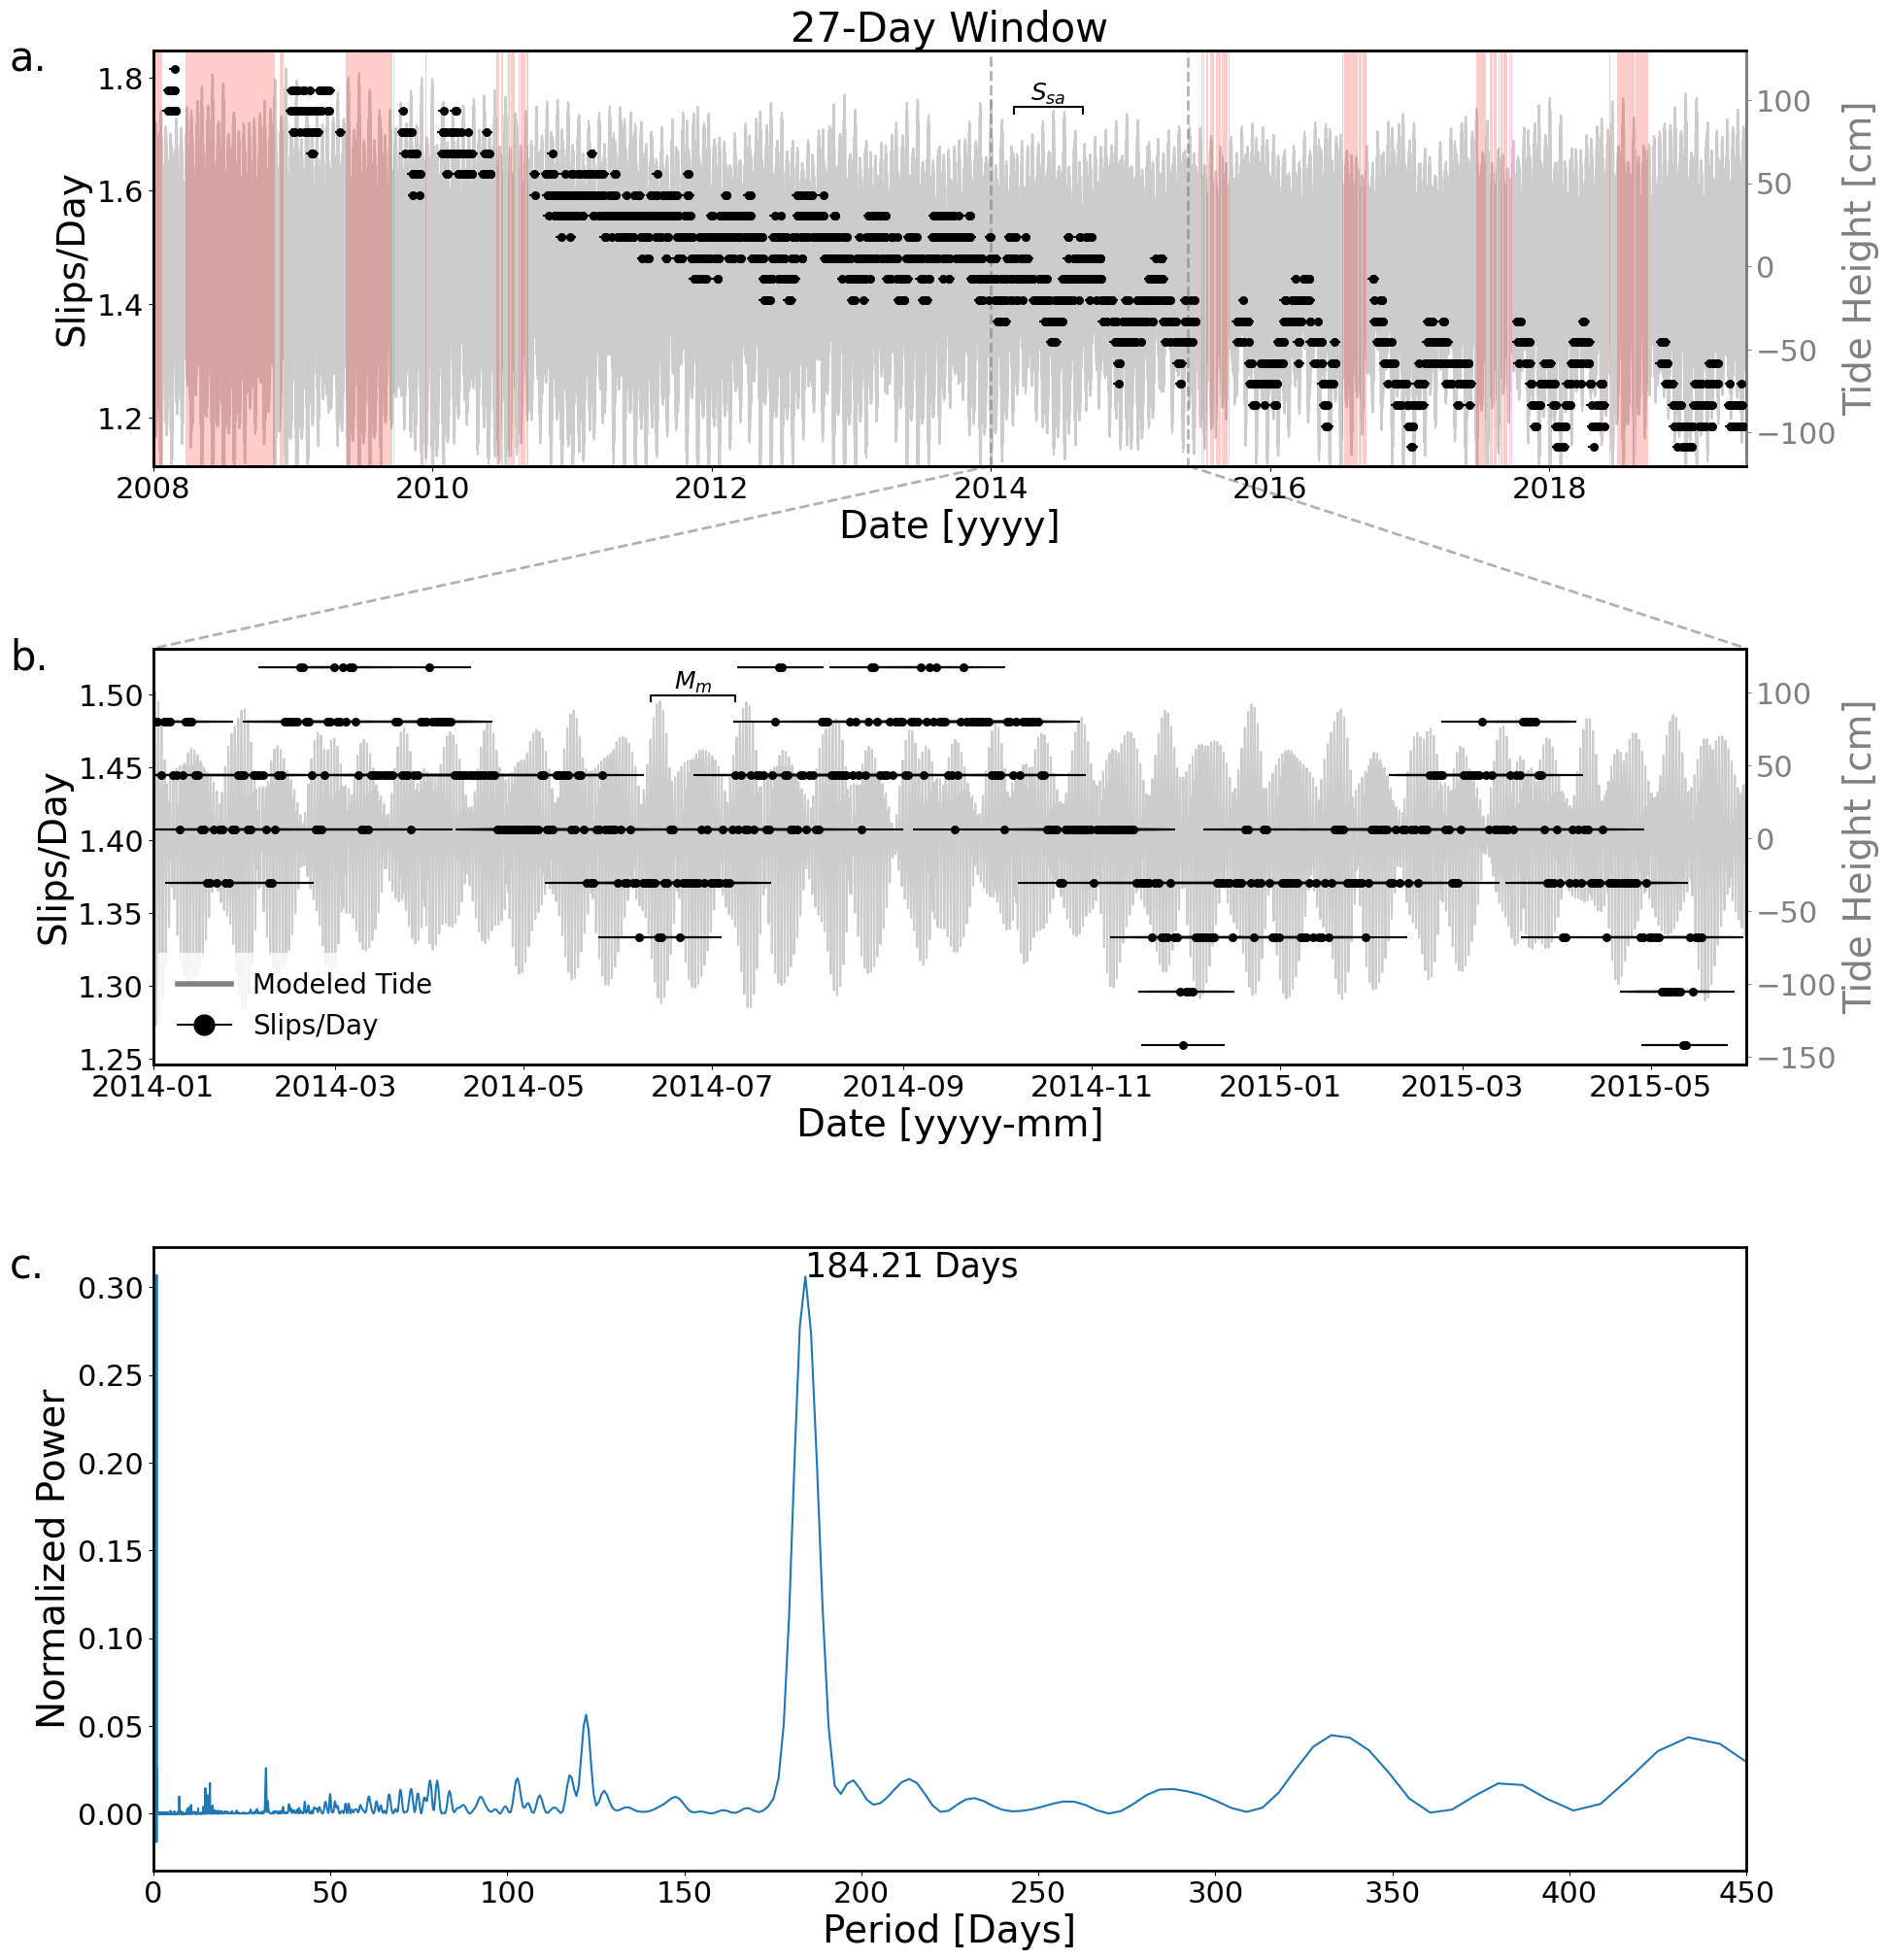

In [28]:
##########
# Figure S4
# Figure S5
##########

# Plot FIGS 4, S4, S5

SEC_TO_DAY = 3600 * 24
SEC_TO_HR = 3600
xlim = 450

viridis = mpl.colormaps["viridis"].resampled(20)
# Add window to rolling avg dict
for i, window in enumerate([3, 27, 45]):
    # for i, window in enumerate([]):
    rolling_avg_dicts[i]["window"] = window

fig_nums = ["S4", "S5"]

for rolling_avg_dict, fignum in zip(rolling_avg_dicts[:2], fig_nums):
    fig = plt.figure(
        figsize=[20, 20],
        constrained_layout=True,
    )
    gs = mpl.gridspec.GridSpec(
        3, 2, figure=fig, width_ratios=[0.9, 0.03], height_ratios=[1, 1, 1.5]
    )
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    skip_starts = rolling_avg_dict["skip_starts"]
    skip_ends = rolling_avg_dict["skip_ends"]
    skip_middles = rolling_avg_dict["skip_middles"]
    skips = rolling_avg_dict["skips"]
    tot_slips = rolling_avg_dict["tot_slips"]
    spacings = rolling_avg_dict["spacings"]
    window = rolling_avg_dict["window"]
    mean_disps = rolling_avg_dict["mean_disps"]
    plot_rolling_avg_section(
        fig,
        ax1,
        ax2,
        window,
        slide,
        skip_starts,
        skip_ends,
        skip_middles,
        skips,
        tot_slips,
        spacings,
        mean_disps,
    )

    # Lomb Scargle
    dates_as_sec = [a.timestamp() for a in skip_middles]
    tot_slips_masked = np.ma.masked_array(
        tot_slips, mask=np.invert(~np.isnan(tot_slips))
    )
    dates_as_sec_masked = np.ma.masked_array(
        dates_as_sec, mask=np.invert(~np.isnan(tot_slips))
    )
    tot_slips_masked = np.ma.compressed(tot_slips_masked)
    dates_as_sec_masked = np.ma.compressed(dates_as_sec_masked)
    tot_slips_detrended = scipy.signal.detrend(tot_slips_masked)

    # Spectrogram of rolling avg slips using lomb scargle
    frequency, power = LombScargle(dates_as_sec_masked, tot_slips_detrended).autopower()

    pks = scipy.signal.find_peaks(power[:10000], height=0.06)[0]
    # ax.plot(frequency[pks], power[pks], 'ro')
    period = 1 / frequency / SEC_TO_DAY  # Days
    ax3.plot(period, power)
    ax3.set_xlabel("Period [Days]", fontsize=28)
    ax3.set_ylabel("Normalized Power", fontsize=28)
    ax3.xaxis.set_tick_params(labelsize=22)
    ax3.yaxis.set_tick_params(labelsize=22)
    ax3.set_xlim(0, xlim)
    # ax.set_ylim(0,0.1)

    for pk, pwr in zip(period[pks], power[pks]):
        if pk < xlim:
            if pk > 0:
                print(f"{pk} Days, Power = {pwr}")
                if pk < 14:
                    ax3.text(pk + 0.001e-5, pwr - 0.005, f"{pk:.2f} Days", fontsize=25)
                else:
                    ax3.text(pk + 0.001e-5, pwr, f"{pk:.2f} Days", fontsize=25)

            else:
                print(f"{pk} Hours, Power = {pwr}")
                ax3.text(pk + 0.001e-5, pwr, f"{pk:.2f} Hours", fontsize=25)

    ax1.annotate("a.", (-0.09, 0.95), xycoords="axes fraction", fontsize=30)
    ax2.annotate("b.", (-0.09, 0.95), xycoords="axes fraction", fontsize=30)
    ax3.annotate("c.", (-0.09, 0.95), xycoords="axes fraction", fontsize=30)

    st3 = datetime.datetime(2014, 1, 1)
    ed3 = datetime.datetime(2015, 6, 1)

    # Adds patch and zoom effect
    rect = plt.Rectangle(
        (st3, -200),
        ed3 - st3,
        1000,
        facecolor="none",
        zorder=0,
        alpha=0.3,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax1.add_patch(rect)

    zoom_effect01(
        ax1,
        ax2,
        mdates.date2num(st3),
        mdates.date2num(ed3),
        ec="black",
        lw=2,
        alpha=0.3,
        ls="--",
    )
    fig.tight_layout()

    legend_elements = [
        Line2D([0], [0], color="gray", lw=4, label="Modeled Tide"),
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            label="Slips/Day",
            markerfacecolor="black",
            markersize=15,
        ),
        # Patch(facecolor='red', edgecolor=None,alpha=0.1,
        #      label='No Data'),
    ]

    legend = ax2.legend(
        handles=legend_elements,
        loc="lower left",
        facecolor=(1, 1, 1, 0.8),
        fontsize=20,
        edgecolor="none",
        ncol=1,
        columnspacing=0.5,
    )
    legend.get_frame().set_boxstyle("Square")
    ax1.set_title(f"{window}-Day Window", fontsize=30)
    fig.savefig(f"Figure{fignum}.png", dpi=300, bbox_inches="tight")

In [ ]:
# Figures S8 and S9
import os
import pandas as pd
import matplotlib.pyplot as plt

# Parameters #
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

catalog = []
for year in years:
    for event in os.listdir(f"../Events_2stas/{year}_{year}Events2stas"):
        catalog.append(
            pd.read_csv(
                f"../Events_2stas/{year}_{year}events2stas/{event}",
                sep="\t",
                index_col=0,
            )
        )

In [ ]:
class SlipDist:
    def __init__(self, catalog, tsle_hr, evt_time, stas):
        self.catalog = catalog
        self.stas = []
        self.disps = []
        self.norm_disps = []
        self.tsle_hr = tsle_hr
        self.event_time = evt_time
        self.interevent_dists = []
        self.norm_interevent_dists = []
        for sta in stas:
            try:
                if catalog[f"{sta}x"].isna().sum() == 0:
                    self.stas.append(sta)
            except KeyError:
                pass

    def get_disps(self):
        for sta in self.stas:
            disp = self.catalog[f"{sta}x"].iloc[-1] - self.catalog[f"{sta}x"].iloc[0]
            self.disps.append(disp)
            self.norm_disps.append(disp)

    def get_interevent_dists(self, slipdist):
        for sta in self.stas:
            if sta in slipdist.stas:
                dist = (
                    self.catalog[f"{sta}x"].iloc[0]
                    - slipdist.catalog[f"{sta}x"].iloc[-1]
                )
                self.interevent_dists.append(dist)
                self.norm_interevent_dists.append(dist)
            else:
                self.interevent_dists.append(np.nan)
                self.norm_interevent_dists.append(np.nan)

In [ ]:
stas = [
    "la01",
    "la02",
    "la03",
    "la04",
    "la05",
    "la06",
    "la07",
    "la08",
    "la09",
    "la10",
    "la11",
    "la12",
    "la13",
    "la14",
    "la15",
    "la16",
    "la17",
    "la18",
    "ws04",
    "ws05",
    "gz01",
    "gz02",
    "gz03",
    "gz04",
    "gz05",
    "gz06",
    "gz07",
    "gz08",
    "gz09",
    "gz10",
    "gz11",
    "gz12",
    "gz13",
    "gz14",
    "gz15",
    "gz16",
    "gz17",
    "gz18",
    "gz19",
    "gz20",
    "mg01",
    "mg02",
    "mg03",
    "mg04",
    "mg05",
    "mg06",
    "mg07",
    "slw1",
]
tsle_hr = [
    (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
]

slip_dists = []
slip_dates = []
for cat, tsle, ev_time in zip(catalog, tsle_hr, ev_data["ev_time"]):
    slip_dist = SlipDist(cat, tsle, ev_time, stas)
    slip_dist.get_disps()
    slip_dists.append(slip_dist)
    slip_dates.append(ev_time)

for i, slip_dist in enumerate(slip_dists):
    if i > 0:
        slip_dist.get_interevent_dists(slip_dists[i - 1])
    # Append nans equal to len of sta for 1st even
slip_dists[0].interevent_dists.append(np.nan)
slip_dists[0].interevent_dists.append(np.nan)
slip_dists[0].norm_interevent_dists.append(np.nan)
slip_dists[0].norm_interevent_dists.append(np.nan)


# Remove > 16m slips from slipdists
slip_dists_rev = []
for slip_dist in slip_dists:
    if slip_dist.tsle_hr < 32:
        slip_dists_rev.append(slip_dist)

slip_dists = slip_dists_rev

In [ ]:
# Find slip dist and interevent dist for la09 only
def la09_slip_dist(slip_dists):
    for sta in stas[:]:
        if sta == "la09":
            # Get slip distance of that station for each event
            disps = [
                slip_dist.disps[slip_dist.stas.index(sta)]
                for slip_dist in slip_dists
                if sta in slip_dist.stas
            ]
            interevent_dists = [
                slip_dist.interevent_dists[slip_dist.stas.index(sta)]
                for slip_dist in slip_dists[:]
                if sta in slip_dist.stas
            ]
            tsle = [
                slip_dist.tsle_hr for slip_dist in slip_dists if sta in slip_dist.stas
            ]
            cat_time_parsed = [
                datetime.datetime.strptime(slip_dist.event_time, "%Y-%m-%d %H:%M:%S")
                for slip_dist in slip_dists
                if sta in slip_dist.stas
            ]

            print(f"{sta} disps: {disps}")
            print(len(disps))
            print(f"{sta} interevent_dists: {interevent_dists}")
            print(len(interevent_dists))
            print(f"{sta} tsle: {tsle}")
            print(len(tsle))
            print(f"{sta} cat_time_parsed: {cat_time_parsed}")
            print(len(cat_time_parsed))

    return disps, interevent_dists, tsle, cat_time_parsed


disps, interevent_dists, tsle_hr, cat_time_parsed = la09_slip_dist(slip_dists)

# Split into 12hr and 24 hr events
slip_dists_12hr = []
slip_dists_24hr = []

for slip_dist in slip_dists:
    if slip_dist.tsle_hr < 18:
        slip_dists_12hr.append(slip_dist)
    else:
        slip_dists_24hr.append(slip_dist)

disps_12hr, interevent_dists_12hr, tsle_hr_12hr, cat_time_parsed_12hr = la09_slip_dist(
    slip_dists_12hr
)
disps_24hr, interevent_dists_24hr, tsle_hr_24hr, cat_time_parsed_24hr = la09_slip_dist(
    slip_dists_24hr
)

# Remove 16 m interevent dist from all arrays

while tsle_hr[interevent_dists.index(np.nanmax(interevent_dists))] > 32:
    max = np.nanmax(interevent_dists)
    print(
        max,
        cat_time_parsed[interevent_dists.index(max)],
        tsle_hr[interevent_dists.index(max)],
    )
    max_index = interevent_dists.index(np.nanmax(interevent_dists))

    disps.pop(max_index)
    interevent_dists.pop(max_index)
    tsle_hr.pop(max_index)
    cat_time_parsed.pop(max_index)

la09 disps: [0.4537989550153725, 0.33349153597373515, 0.367943363788072, 0.31270637188572437, 0.36662080115638673, 0.3073474850971252, 0.3594028131919913, 0.32087884412612766, 0.3435042940545827, 0.3179356876644306, 0.35182992118643597, 0.3067352760117501, 0.41560153814498335, 0.39739241515053436, 0.317925569426734, 0.4082711798255332, 0.3902799971983768, 0.5043259396916255, 0.38765557477017865, 0.342267133470159, 0.3186909730429761, 0.44969603448407724, 0.3483014810481109, 0.3079928443185054, 0.45186540932627395, 0.35489979333942756, 0.34059936145786196, 0.32797535660210997, 0.34256289346376434, 0.31985371257178485, 0.3586191655485891, 0.3179751898860559, 0.37165312335127965, 0.28984075359767303, 0.35931014601374045, 0.39273855125065893, 0.3420455231098458, 0.3875900141429156, 0.3030625642859377, 0.35940082935849205, 0.32319498498691246, 0.32692139060236514, 0.3084504090365954, 0.3359111355384812, 0.3561398832243867, 0.3238879005657509, 0.4542439230135642, 0.4492035512230359, 0.314325

[87.77710078295786, 105.59746519243345, 99.02956575539429, 102.66371815849561, 117.55908770282986, 92.18259162682807, 90.11420580768026, 55.70575574284885, 81.0106400338118, 39.58539794670651]
[432, 489, 460, 482, 516, 390, 386, 230, 340, 163]


0.05835025869610582
0.09908902741407898
0.3583848492475855
0.22705903798540175


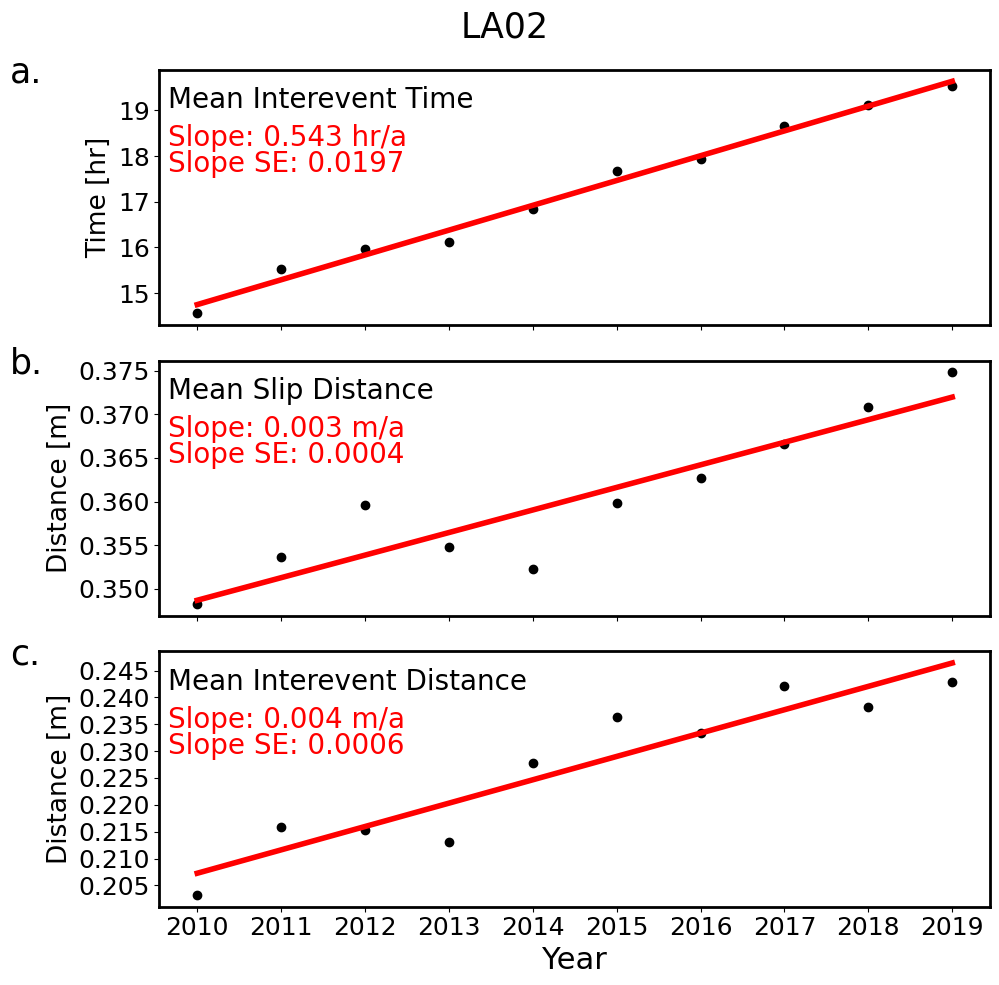

In [ ]:
###########
# Figure S8
###########

# Cummulative tots for each year
# Remember LA09 is flipped with LA02 in the dataset

years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
tots = {
    "years": years,
    "disps": [],
    "interevent_dists": [],
    "tsle_hr": [],
    "num_events": [],
}


for year in tots["years"]:
    tot = 0
    inter = 0
    count = 0
    time = 0
    for disp, idist, tsle, parsed in zip(
        disps, interevent_dists, tsle_hr, cat_time_parsed
    ):
        if parsed.year == year:
            tot += disp
            count += 1
            if not math.isnan(idist):
                inter += idist
            if not math.isnan(tsle):
                time += tsle
    tots["disps"].append(tot)
    tots["interevent_dists"].append(inter)
    tots["tsle_hr"].append(time)
    tots["num_events"].append(count)

print(tots["interevent_dists"])
print(tots["num_events"])
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=[10, 10], sharex=True)
inter_norm = [a / b for a, b in zip(tots["tsle_hr"], tots["num_events"])]
ax1.scatter(tots["years"], inter_norm, label="Slip", color="black")
ax1.set_ylabel("Time [hr]", size=19)
ax1.text(0.01, 0.85, "Mean Interevent Time", transform=ax1.transAxes, fontsize=20)
ax1.xaxis.set_tick_params(labelsize=18)
ax1.yaxis.set_tick_params(labelsize=18)
ax1.yaxis.set_major_locator(plt.MaxNLocator(6))

slipdist_norm = [a / b for a, b in zip(tots["disps"], tots["num_events"])]
ax2.scatter(tots["years"], slipdist_norm, label="Slip", color="black")
ax2.set_ylabel("Distance [m]", size=19)
ax2.text(0.01, 0.85, "Mean Slip Distance", transform=ax2.transAxes, fontsize=20)
ax2.xaxis.set_tick_params(labelsize=18)
ax2.yaxis.set_tick_params(labelsize=18)
ax2.yaxis.set_major_locator(plt.MaxNLocator(6))

interevent_norm = [a / b for a, b in zip(tots["interevent_dists"], tots["num_events"])]
ax3.scatter(tots["years"], interevent_norm, color="black")
ax3.set_ylabel("Distance [m]", size=19)
ax3.text(0.01, 0.85, "Mean Interevent Distance", transform=ax3.transAxes, fontsize=20)
ax3.xaxis.set_tick_params(labelsize=18)
ax3.yaxis.set_tick_params(labelsize=18)
# Add more ytics every .005
ax3.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.005))
ax3.set_xticks(tots["years"])


ax1.annotate("a.", (-0.18, 0.95), xycoords="axes fraction", fontsize=25)
ax2.annotate("b.", (-0.18, 0.95), xycoords="axes fraction", fontsize=25)
ax3.annotate("c.", (-0.18, 0.95), xycoords="axes fraction", fontsize=25)
ax3.set_xlabel("Year", size=22)
fig.suptitle("LA02", size=25)


# Best fit lines for each plot
def plot_line(ax, yrs, vals, unit):
    # masked_hr_sec_mas = np.ma.masked_where(np.array(hr_since_last_ev) > 32, masked_hr_sec)
    m, b, r_value, p_value, std_err = scipy.stats.linregress(yrs, vals)
    ax.plot(yrs, m * np.array(yrs) + b, color="red", linewidth=4)
    ax.text(
        0.01,
        0.7,
        f"Slope: {m:.3f} {unit}/a",
        transform=ax.transAxes,
        fontsize=20,
        color="red",
    )
    ax.text(
        0.01,
        0.6,
        f"Slope SE: {std_err:.4f}",
        transform=ax.transAxes,
        fontsize=20,
        color="red",
    )
    return m


m1 = plot_line(ax1, tots["years"], inter_norm, "hr")
m2 = plot_line(ax2, tots["years"], slipdist_norm, "m")
m3 = plot_line(ax3, tots["years"], interevent_norm, "m")

fig.tight_layout()


print(np.std(disps))
print(np.nanstd(interevent_dists))
print(np.mean(disps))
print(np.nanmean(interevent_dists))

fig.savefig("FigureS8.png", dpi=300)

In [ ]:
def z_score(slip_dists):
    # Find z score for each sta and each event
    for sta in stas[:]:
        # Get slip distance of that station for each event
        disps = [
            slip_dist.disps[slip_dist.stas.index(sta)]
            for slip_dist in slip_dists
            if sta in slip_dist.stas
        ]
        disp_zscores = scipy.stats.zscore(disps)

        # Get interevent distances
        interevent_dists = [
            slip_dist.interevent_dists[slip_dist.stas.index(sta)]
            for slip_dist in slip_dists[:]
            if sta in slip_dist.stas
        ]
        mean_interevent_dist = np.nanmean(interevent_dists)
        std_interevent_dist = np.nanstd(interevent_dists)

        # Calculate z score
        count = 0
        for slip_dist in slip_dists:
            if sta in slip_dist.stas:
                slip_dist.norm_disps[slip_dist.stas.index(sta)] = disp_zscores[count]
                # slip_dist.norm_disps[slip_dist.stas.index(sta)] = (slip_dist.norm_disps[slip_dist.stas.index(sta)] - mean_disp)/std_disp
                slip_dist.norm_interevent_dists[slip_dist.stas.index(sta)] = (
                    slip_dist.norm_interevent_dists[slip_dist.stas.index(sta)]
                    - mean_interevent_dist
                ) / std_interevent_dist
                count += 1

    # mean_slip = [np.mean(slip_dist.disps) for slip_dist in slip_dists]
    mean_z_slip = [np.mean(slip_dist.norm_disps) for slip_dist in slip_dists]
    mean_interevent = [
        np.nanmean(slip_dist.interevent_dists) for slip_dist in slip_dists
    ]
    mean_z_interevent = [
        np.nanmean(slip_dist.norm_interevent_dists) for slip_dist in slip_dists
    ]

    return mean_z_slip, mean_z_interevent, mean_interevent

In [ ]:
# Split into 12hr and 24 hr events
slip_dists_12hr = []
slip_dists_24hr = []

for slip_dist in slip_dists:
    if slip_dist.tsle_hr < 18:
        slip_dists_12hr.append(slip_dist)
    else:
        slip_dists_24hr.append(slip_dist)
print(len(slip_dists_12hr), len(slip_dists_24hr))

mean_z_slip, mean_z_interevent, mean_interevent = z_score(slip_dists)
cat_time = [
    datetime.datetime.strptime(slip_dist.event_time, "%Y-%m-%d %H:%M:%S")
    for slip_dist in slip_dists
]
tsle_hr = [slip_dist.tsle_hr for slip_dist in slip_dists]
print(
    len(mean_z_slip),
    len(mean_z_interevent),
    len(mean_interevent),
    len(cat_time),
    len(tsle_hr),
)

mean_z_slip_12hr, mean_z_interevent_12hr, mean_interevent_12hr = z_score(
    slip_dists_12hr
)
mean_z_slip_24hr, mean_z_interevent_24hr, mean_interevent_24hr = z_score(
    slip_dists_24hr
)

# Split evtime into 12hr and 24hr
ev_time_12hr = []
ev_time_24hr = []
tsle_12 = []
tsle_24 = []
for ev_time, tsle in zip(ev_data["ev_time"], tsle_hr):
    if tsle < 18:
        ev_time_12hr.append(ev_time)
        tsle_12.append(tsle)
    else:
        ev_time_24hr.append(ev_time)
        tsle_24.append(tsle)

print(len(ev_time_12hr), len(ev_time_24hr))

3120 1765
4885 4885 4885 4885 4885
3120 1765


3.897176931213492
2.841468718451047
3.4928748457892134
5.082413647733893
3.469468749759384
3.6843765396308985
2.5856619791620234
2.4947276158330913
1.7933499150845915
1.3670208665246306
3.2369405273820524
3.877085972232315
2.6236711336733047
2.66525965755259
1.4705492915504546
1.7531680782351995
0.48513065799813515
0.7609827482845188
-0.4025615727775913
-1.5692602144110637
-1.099156377300306
-1.9320146835265397
-1.8653506533051338
0.050900142107226154
-0.3376508688811743
-0.881870082044379
0.36643271718772774
-0.5384527854289759
-0.7941657572462588
0.33911493579483043
2.0546329726711146
2.632818138128775
1.759200693881787
1.3233131715320106
0.5321365705228459
0.1276715669720141
-0.700841729866497
-1.1177800454150293
-2.0214647675335655
-2.2666754937686777
-3.093135668444134
-3.21935709494076
-4.076677177504096
-3.8668914683049245
-2.000222945922105
-2.8611209122068404
-2.8643723285607505
-3.6121443980969112
-3.4762327819000443
-4.449693247860431
-3.9784716002146867
-3.6529959347255536


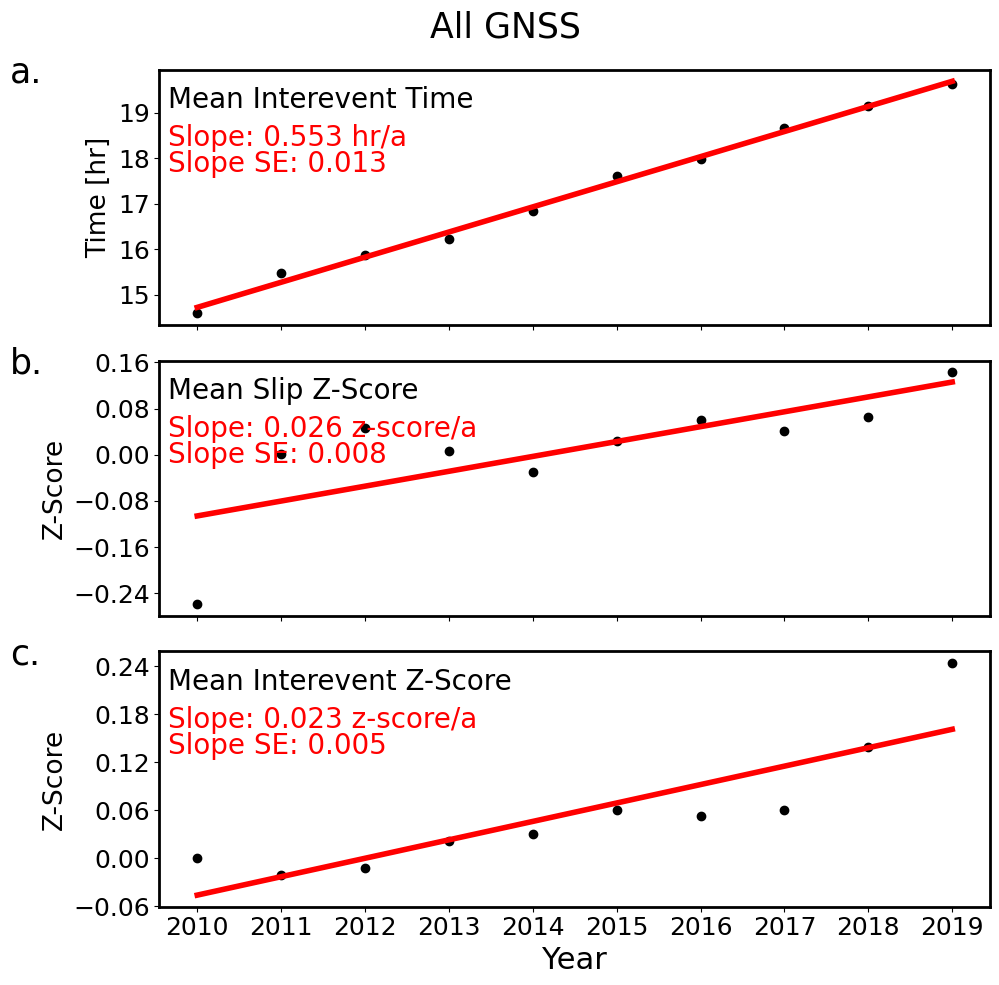

In [ ]:
###########
# Figure S9
###########

years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
tots = {
    "years": years,
    "disps": [],
    "interevent_dists": [],
    "tsle_hr": [],
    "num_events": [],
}


for year in tots["years"]:
    tot = 0
    inter = 0
    count = 0
    time = 0
    for disp, idist, tsle, parsed in zip(
        mean_z_slip, mean_z_interevent, tsle_hr, cat_time
    ):
        if parsed.year == year:
            tot += disp
            count += 1
            if not math.isnan(idist):
                inter += idist
                print(inter)
            if not math.isnan(tsle):
                time += tsle
    tots["disps"].append(tot)
    tots["interevent_dists"].append(inter)
    tots["tsle_hr"].append(time)
    tots["num_events"].append(count)

print(tots["interevent_dists"])
print(tots["num_events"])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=[10, 10], sharex=True)
inter_norm = [a / b for a, b in zip(tots["tsle_hr"], tots["num_events"])]
print(tots["years"], inter_norm)
ax1.scatter(tots["years"], inter_norm, label="Slip", color="black")
ax1.set_ylabel("Time [hr]", size=19)
ax1.text(0.01, 0.85, "Mean Interevent Time", transform=ax1.transAxes, fontsize=20)
ax1.xaxis.set_tick_params(labelsize=18)
ax1.yaxis.set_tick_params(labelsize=18)
ax1.yaxis.set_major_locator(plt.MaxNLocator(6))

slipdist_norm = [a / b for a, b in zip(tots["disps"], tots["num_events"])]
ax2.scatter(tots["years"], slipdist_norm, label="Slip", color="black")
print(tots["years"], slipdist_norm)
ax2.set_ylabel("Z-Score", size=19)
ax2.text(0.01, 0.85, "Mean Slip Z-Score", transform=ax2.transAxes, fontsize=20)
ax2.xaxis.set_tick_params(labelsize=18)
ax2.yaxis.set_tick_params(labelsize=18)
ax2.yaxis.set_major_locator(plt.MaxNLocator(6))

interevent_norm = [a / b for a, b in zip(tots["interevent_dists"], tots["num_events"])]
ax3.scatter(tots["years"], interevent_norm, color="black")
print(tots["years"], interevent_norm)
ax3.set_ylabel("Z-Score", size=19)
ax3.text(0.01, 0.85, "Mean Interevent Z-Score", transform=ax3.transAxes, fontsize=20)
ax3.xaxis.set_tick_params(labelsize=18)
ax3.yaxis.set_tick_params(labelsize=18)
# Add more ytics every .005
ax3.yaxis.set_major_locator(plt.MaxNLocator(6))
ax3.set_xticks(tots["years"])


ax1.annotate("a.", (-0.18, 0.95), xycoords="axes fraction", fontsize=25)
ax2.annotate("b.", (-0.18, 0.95), xycoords="axes fraction", fontsize=25)
ax3.annotate("c.", (-0.18, 0.95), xycoords="axes fraction", fontsize=25)
ax3.set_xlabel("Year", size=22)
fig.suptitle("All GNSS", size=25)


# Best fit lines for each plot
def plot_line(ax, yrs, vals, unit):
    # masked_hr_sec_mas = np.ma.masked_where(np.array(hr_since_last_ev) > 32, masked_hr_sec)
    m, b, r_value, p_value, std_err = scipy.stats.linregress(yrs, vals)
    ax.plot(yrs, m * np.array(yrs) + b, color="red", linewidth=4)
    ax.text(
        0.01,
        0.7,
        f"Slope: {m:.3f} {unit}/a",
        transform=ax.transAxes,
        fontsize=20,
        color="red",
    )
    ax.text(
        0.01,
        0.6,
        f"Slope SE: {std_err:.3f}",
        transform=ax.transAxes,
        fontsize=20,
        color="red",
    )
    return m


m1 = plot_line(ax1, tots["years"], inter_norm, "hr")
m2 = plot_line(ax2, tots["years"], slipdist_norm, "z-score")
m3 = plot_line(ax3, tots["years"], interevent_norm, "z-score")

fig.tight_layout()

print(np.std(mean_z_slip))
print(np.std(mean_z_interevent))

fig.savefig("FigureS9.png", dpi=300)

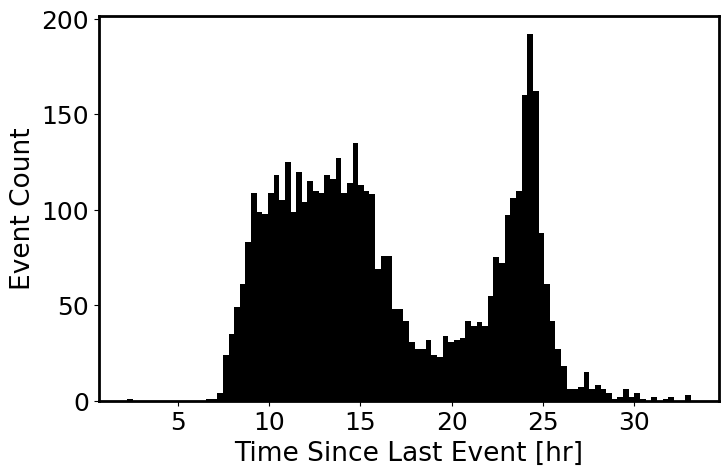

In [ ]:
# FIGURE S10
# Interevent duration histogram
tsle_hr = [
    (a.days * 24 * 3600 + a.seconds) / 3600 for a in ev_data["time_since_last_ev"]
]

# Remove all values > 50
tsle_hr = [x for x in tsle_hr if x < 50]

fig, ax = plt.subplots(figsize=[8, 5])
# Set start and end bins
st = 0
ed = 48
# Set number of bins
bins = 100
# Plot histogram
n, bins, patches = ax.hist(tsle_hr, bins=bins, color="black")

ax.set_ylabel("Event Count", size=19)
ax.set_xlabel("Time Since Last Event [hr]", size=19)
ax.xaxis.set_tick_params(labelsize=18)
ax.yaxis.set_tick_params(labelsize=18)
fig.savefig("FigureS10.png", dpi=300, bbox_inches="tight")